In [ ]:
import os

# Uses all CPU cores in your computer or Phelma Machines
os.environ["OMP_NUM_THREADS"] = str(os.cpu_count())  
os.environ["OPENBLAS_NUM_THREADS"] = str(os.cpu_count())
os.environ["MKL_NUM_THREADS"] = str(os.cpu_count())
os.environ["VECLIB_MAXIMUM_THREADS"] = str(os.cpu_count())
os.environ["NUMEXPR_NUM_THREADS"] = str(os.cpu_count())

# Display image

C:\Temp\ipykernel_35504\3877024957.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image, cmap = 'gray')
c:\Users\Shivraj Sarode\anaconda3\envs\Phelma\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


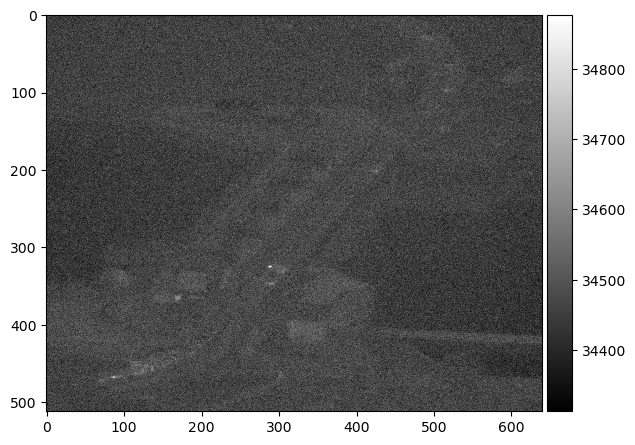

In [71]:
from skimage import io
import numpy as np
image=io.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\result\frame_0100.png")
io.imshow(image, cmap = 'gray')

#### Normalisation min-max simple : image_8bit = (image_16bit - min) / (max - min) * 255

C:\Temp\ipykernel_35504\881963002.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final)


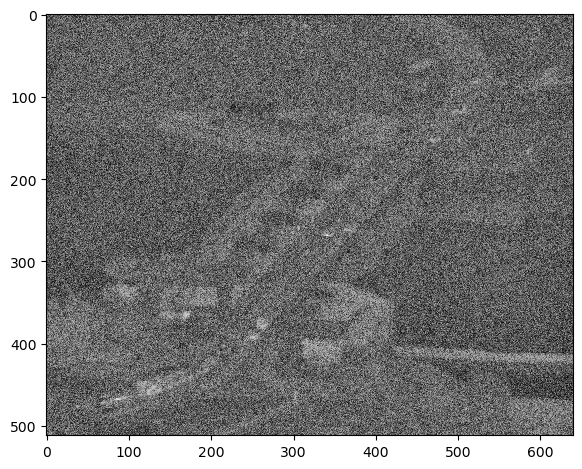

In [3]:
import cv2
import numpy as np

# Conversion nécessaire pour CLAHE (qui travaille en 8 bits)
img_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_final = clahe.apply(img_8bit)
io.imshow(img_final)

## To ckeck if the defect column width is one pixel wide or more

In [44]:
import cv2
import numpy as np

# Load as 16-bit (UNCHANGED)
img = cv2.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0000.png")
# print (img)

# Pick a row in the middle (e.g., row 100)
# Let's look at the area around column 150 (change this to your suspect column)
suspect_col = 450 
row_data = img[300, suspect_col-10 : suspect_col+10]
l = 0
defect_column = 468
defect = []
for l in range (512):
    defect.append((l,defect_column))
# print(f"Values around column {suspect_col}:")
print(row_data)
list_of_rows = []
print (defect[0])
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)



[[130 130 130]
 [130 130 130]
 [130 130 130]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [130 130 130]
 [130 130 130]
 [130 130 130]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [130 130 130]
 [130 130 130]
 [129 129 129]
 [129 129 129]
 [129 129 129]
 [129 129 129]]
(0, 468)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,

Now we know that for this image there is a defect on column 468. 

## For defect correction using mean

[(0, [325, 395, 450]), (1, [325, 395, 450]), (2, [325, 395, 450]), (3, [325, 395, 450]), (4, [325, 395, 450]), (5, [325, 395, 450]), (6, [325, 395, 450]), (7, [325, 395, 450]), (8, [325, 395, 450]), (9, [325, 395, 450]), (10, [325, 395, 450]), (11, [325, 395, 450]), (12, [325, 395, 450]), (13, [325, 395, 450]), (14, [325, 395, 450]), (15, [325, 395, 450]), (16, [325, 395, 450]), (17, [325, 395, 450]), (18, [325, 395, 450]), (19, [325, 395, 450]), (20, [325, 395, 450]), (21, [325, 395, 450]), (22, [325, 395, 450]), (23, [325, 395, 450]), (24, [325, 395, 450]), (25, [325, 395, 450]), (26, [325, 395, 450]), (27, [325, 395, 450]), (28, [325, 395, 450]), (29, [325, 395, 450]), (30, [325, 395, 450]), (31, [325, 395, 450]), (32, [325, 395, 450]), (33, [325, 395, 450]), (34, [325, 395, 450]), (35, [325, 395, 450]), (36, [325, 395, 450]), (37, [325, 395, 450]), (38, [325, 395, 450]), (39, [325, 395, 450]), (40, [325, 395, 450]), (41, [325, 395, 450]), (42, [325, 395, 450]), (43, [325, 395, 450]

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

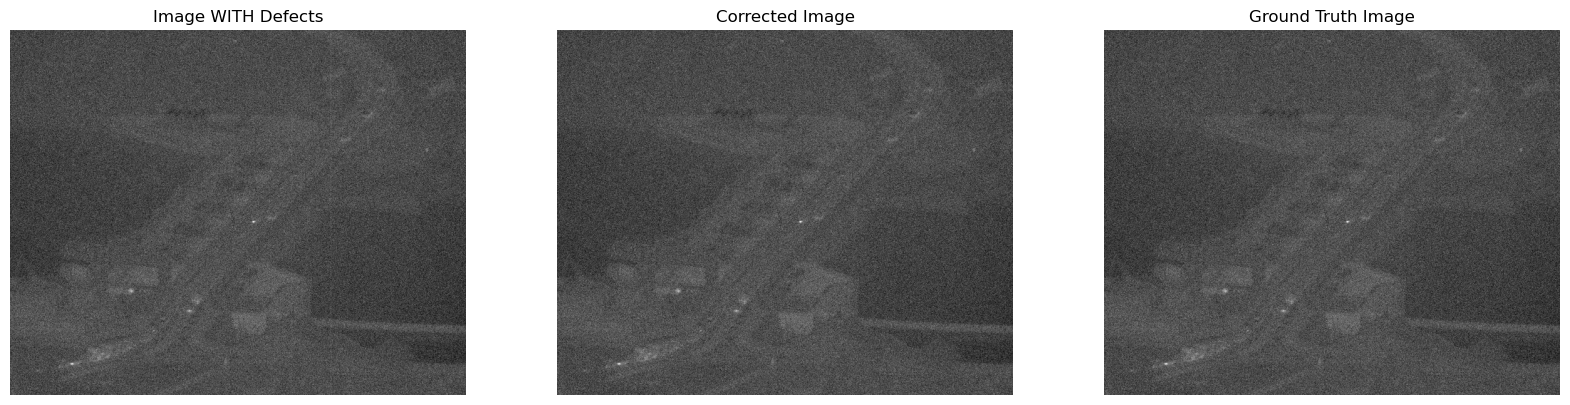

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load as 16-bit 
img = cv2.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0000.png",cv2.IMREAD_UNCHANGED)
# print (img)
gt = cv2.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0000.png",cv2.IMREAD_UNCHANGED)

defect_column = [325, 395, 450]
defect = []
for l in range (512):
    defect.append((l,defect_column))

print (defect)
# print (img[0][0])

list_of_rows = []
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)

def correct_defect(image, defects):
    '''
    defects = multiple array of defective pixels
    for current_defect in the defects array
        for defect[row] in image, 
            image [row:column] = (image [row:column+1] + image [row:column-1])/2
    
    ADD ANOTHER LOOP OVER THE ONE HERE FOR DEALING WITH MULTIPLE DEFECT COLUMNS
    '''
    copy_img = image.copy()
    for dfct in defect_column:
        for row in list_of_rows:
            copy_img [row,dfct] = (copy_img [row,dfct+1].astype(np.float32) + copy_img [row,dfct-1].astype(np.float32))/2
    
    return copy_img

corr_img = correct_defect(img,defect)
diffrence = corr_img - img

fig, axs = plt.subplots(1, 3, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Image WITH Defects')
axs[0].axis('off')
axs[1].imshow(corr_img, cmap='gray')
axs[1].set_title('Corrected Image')
axs[1].axis('off')
axs[2].imshow(gt, cmap='gray')
axs[2].set_title('Ground Truth Image')
axs[2].axis('off')

In [ ]:
# Save file
import cv2
import os

# Define the desktop path dynamically for your computer
desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'corrected_frame_2pixel.png')

# Save the image
# 'corr_img' is the variable from your previous code
success = cv2.imwrite(save_path, corr_img)

if success:
    print(f"File saved successfully to: {save_path}")
else:
    print("Error: Could not save the image.")

File saved successfully to: C:\Users\Shivraj Sarode\Desktop\corrected_frame_2pixel.png


## Using 6 surrounding pixels

[(0, [325, 395, 450]), (1, [325, 395, 450]), (2, [325, 395, 450]), (3, [325, 395, 450]), (4, [325, 395, 450]), (5, [325, 395, 450]), (6, [325, 395, 450]), (7, [325, 395, 450]), (8, [325, 395, 450]), (9, [325, 395, 450]), (10, [325, 395, 450]), (11, [325, 395, 450]), (12, [325, 395, 450]), (13, [325, 395, 450]), (14, [325, 395, 450]), (15, [325, 395, 450]), (16, [325, 395, 450]), (17, [325, 395, 450]), (18, [325, 395, 450]), (19, [325, 395, 450]), (20, [325, 395, 450]), (21, [325, 395, 450]), (22, [325, 395, 450]), (23, [325, 395, 450]), (24, [325, 395, 450]), (25, [325, 395, 450]), (26, [325, 395, 450]), (27, [325, 395, 450]), (28, [325, 395, 450]), (29, [325, 395, 450]), (30, [325, 395, 450]), (31, [325, 395, 450]), (32, [325, 395, 450]), (33, [325, 395, 450]), (34, [325, 395, 450]), (35, [325, 395, 450]), (36, [325, 395, 450]), (37, [325, 395, 450]), (38, [325, 395, 450]), (39, [325, 395, 450]), (40, [325, 395, 450]), (41, [325, 395, 450]), (42, [325, 395, 450]), (43, [325, 395, 450]

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

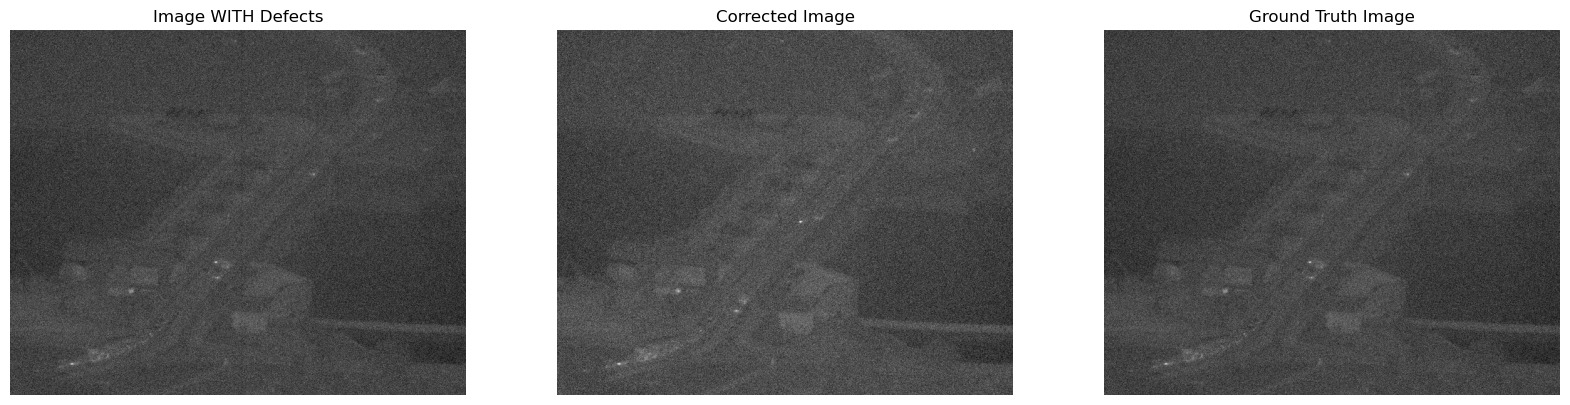

In [6]:
import cv2
import numpy as np

# Load as 16-bit 
img = cv2.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0100.png",cv2.IMREAD_UNCHANGED)
# print (img)
gt = cv2.imread(r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0100.png",cv2.IMREAD_UNCHANGED)
defect_column = [325, 395, 450]
defect = []
for l in range (511):
    defect.append((l,defect_column))

print (defect)
# print (img[0][0])

list_of_rows = []
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)

def correct_defect(image, defects):
    '''
    defects = multiple array of defective pixels
    for current_defect in the defects array
        for defect[row] in image, 
            image [row:column] = (image [row:column+1] + image [row:column-1])/2
    
    ADD ANOTHER LOOP OVER THE ONE HERE FOR DEALING WITH MULTIPLE DEFECT COLUMNS
    '''
    copy_img = image.copy()
    # Replaces the entire row-by-row loop
    for dfct in defect_column:
        copy_img[:, dfct] = np.mean(img[:, [dfct-3, dfct-2, dfct-1, dfct+1, dfct+2, dfct+3]], axis=1)
    return copy_img

corr_img_6 = correct_defect(img,defect)
diffrence = corr_img - img

fig, axs = plt.subplots(1, 3, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Image WITH Defects')
axs[0].axis('off')
axs[1].imshow(corr_img, cmap='gray')
axs[1].set_title('Corrected Image')
axs[1].axis('off')
axs[2].imshow(gt, cmap='gray')
axs[2].set_title('Ground Truth Image')
axs[2].axis('off')

In [ ]:
# save image
import cv2
import os

# Define the desktop path dynamically for your computer
desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'corrected_frame_6pixel.png')

# Save the image
# 'corr_img' is the variable from your previous code
success = cv2.imwrite(save_path, corr_img_6)

if success:
    print(f"File saved successfully to: {save_path}")
else:
    print("Error: Could not save the image.")

File saved successfully to: C:\Users\Shivraj Sarode\Desktop\corrected_frame_6pixel.png


In [26]:
import os
import json
import cv2
import numpy as np
from pathlib import Path

def evaluate_single_image(img_without_defect, img_with_defect, img_eval_path, json_path=None):
    """
    Évalue une image corrigée en la comparant à l'originale (100%) et à la base défectueuse (0%).
    """

    # ==========================================
    # Fonctions utilitaires intégrées
    # ==========================================
    def read_json(p):
        p = Path(p)
        if not p.is_file():
            raise FileNotFoundError(f"Fichier introuvable : {p}")
        return json.loads(p.read_text(encoding="utf-8"))

    def process_json(data):
        indices = []
        for c in data:
            indices += c["x_coord"]
        return np.array(indices, dtype=int)

    def load_image(path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Image introuvable : {path}")
        return cv2.imread(path, -1).astype(np.float32, copy=False)

    # ==========================================
    # Chargement des images
    # ==========================================
    gt = load_image(img_without_defect)      # 100% Original (Ground Truth)
    base = load_image(img_with_defect)      # 0% Défectueux (Base)
    res = load_image(img_eval_path)    # Image à évaluer

    if gt.shape != base.shape or gt.shape != res.shape:
        raise ValueError("Les trois images doivent avoir exactement la même résolution.")

    nb_cols = gt.shape[1]

    # ==========================================
    # Calcul des erreurs globales pour la similarité
    # ==========================================
    # Erreur totale de l'image de base (non corrigée) par rapport au 100%
    diff_base_sq = ((base - gt) ** 2).sum(axis=0)
    ssd_base = diff_base_sq.sum()

    # Erreur totale de l'image évaluée (corrigée) par rapport au 100%
    residu_sq = ((res - gt) ** 2).sum(axis=0)
    ssd_eval = residu_sq.sum()

    # Calcul du niveau de similarité (0% = image base, 100% = image parfaite)
    if ssd_base > 0:
        similarite = 100.0 * (1.0 - (ssd_eval / ssd_base))
    else:
        similarite = 100.0  # Si l'image de base n'avait aucun défaut dès le départ

    # ==========================================
    # Identification des colonnes défectueuses
    # ==========================================
    if json_path and os.path.exists(json_path):
        true_def = process_json(read_json(json_path))
    else:
        true_def = np.flatnonzero(diff_base_sq)

    true_mask = np.isin(np.arange(nb_cols), true_def)

    # ==========================================
    # Évaluation de la détection (res)
    # ==========================================
    detected = np.flatnonzero(residu_sq)

    # Calcul des TP, FP, FN
    tp = np.intersect1d(detected, true_def, assume_unique=True).size
    fp = np.setdiff1d(detected, true_def, assume_unique=True).size
    fn = np.setdiff1d(true_def, detected, assume_unique=True).size

    mask_def = true_mask
    mask_ok  = ~true_mask

    sq_def = (residu_sq[mask_def]).sum()
    cnt_def = mask_def.sum() * gt.shape[0]

    sq_ok  = (residu_sq[mask_ok]).sum()
    cnt_ok = mask_ok.sum() * gt.shape[0]

    nb_cols_f = float(nb_cols)
    tp_norm = tp / nb_cols_f
    fp_norm = fp / nb_cols_f
    fn_norm = fn / nb_cols_f

    prec = tp_norm / (tp_norm + fp_norm) if (tp_norm + fp_norm) else 0.0
    rec  = tp_norm / (tp_norm + fn_norm) if (tp_norm + fn_norm) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    
    rmse_def = np.sqrt(sq_def / cnt_def) if cnt_def else 0.0
    rmse_ok  = np.sqrt(sq_ok  / cnt_ok ) if cnt_ok  else 0.0

    # Retourner les résultats (j'ai enlevé les anciens RMSE normalisés qui ne te servent plus)
    return {
        "TP_norm": round(tp_norm, 6),
        "FP_norm": round(fp_norm, 6),
        "FN_norm": round(fn_norm, 6),
        "Precision": round(prec, 6),
        "Recall": round(rec, 6),
        "F1_Score": round(f1, 6),
        "RMSE_def": round(rmse_def, 6),
        "RMSE_ok": round(rmse_ok, 6),
        "Similarite_GT_pct": round(similarite, 2) # Arrondi à 2 décimales pour faire "pourcentage"
    }

def print_metrics_table(metrics):
    """
    Affiche un dictionnaire de métriques sous la forme d'un tableau formaté dans la console.
    """
    col_metrique = 20
    col_valeur = 12
    ligne_separatrice = "+" + "-" * (col_metrique + 2) + "+" + "-" * (col_valeur + 2) + "+"
    
    print("\nRÉSULTATS DE L'ÉVALUATION")
    print(ligne_separatrice)
    print(f"| {'Métrique'.ljust(col_metrique)} | {'Valeur'.rjust(col_valeur)} |")
    print(ligne_separatrice)
    
    for key, value in metrics.items():
        if key == "Similarite_GT_pct":
            print(ligne_separatrice)
            formatted_value = f"{value:.2f} %"
        else:
            formatted_value = f"{value:.6f}" if isinstance(value, float) else str(value)
            
        print(f"| {key.ljust(col_metrique)} | {formatted_value.rjust(col_valeur)} |")
        
    print(ligne_separatrice)

In [27]:
if __name__ == "__main__":
    resultats = evaluate_single_image(
        img_without_defect=r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png',
        img_with_defect=r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png',
        img_eval_path=r'C:\Users\Shivraj Sarode\Desktop\with noise.png'
    )

    print(f"\nNiveau de similarité avec l'image parfaite : {resultats['Similarite_GT_pct']} %")
    print_metrics_table(resultats)


Niveau de similarité avec l'image parfaite : -86.9000015258789 %

RÉSULTATS DE L'ÉVALUATION
+----------------------+--------------+
| Métrique             |       Valeur |
+----------------------+--------------+
| TP_norm              |     0.003125 |
| FP_norm              |     0.001563 |
| FN_norm              |     0.000000 |
| Precision            |     0.666667 |
| Recall               |     1.000000 |
| F1_Score             |     0.800000 |
| RMSE_def             |    23.926972 |
| RMSE_ok              |     1.248819 |
+----------------------+--------------+
| Similarite_GT_pct    |     -86.90 % |
+----------------------+--------------+


(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

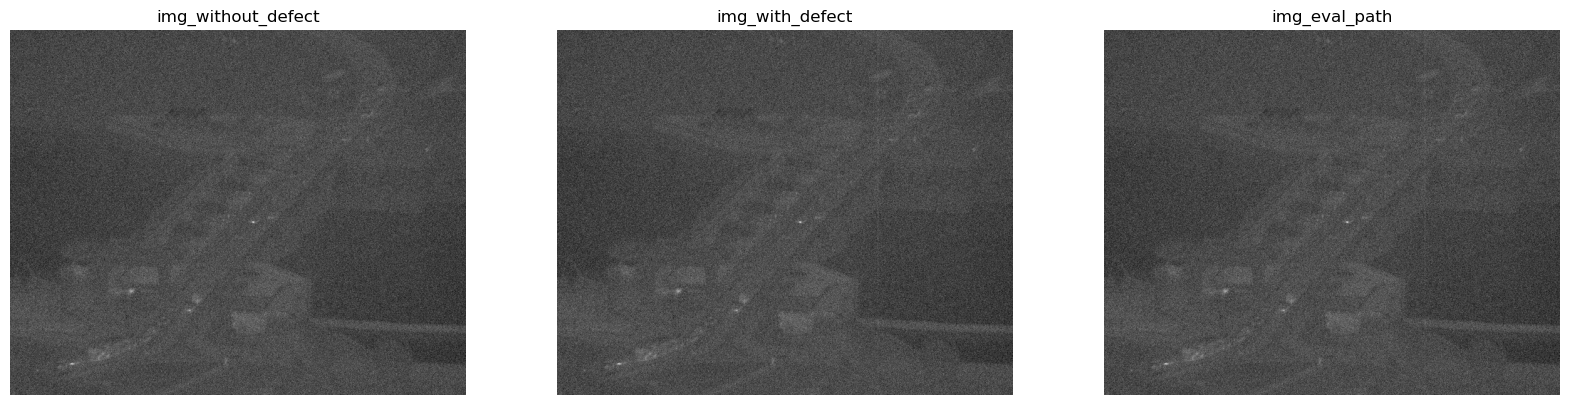

In [25]:
img_without_defect = io.imread(r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png')
img_with_defect = io.imread(r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png')
img_eval_path = io.imread(r'C:\Users\Shivraj Sarode\Desktop\with noise.png')
fig, axs = plt.subplots(1, 3, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(img_without_defect, cmap='gray')
axs[0].set_title('img_without_defect')
axs[0].axis('off')
axs[1].imshow(img_with_defect, cmap='gray')
axs[1].set_title('img_with_defect')
axs[1].axis('off')
axs[2].imshow(img_eval_path, cmap='gray')
axs[2].set_title('img_eval_path')
axs[2].axis('off')

## For telling if the defect is only 1 column wide or 4 column wide or more

In [ ]:
import cv2
import numpy as np

# Load as 16-bit (UNCHANGED)
img = cv2.imread('frame_0000_VGA_seq2_column2.jpg', cv2.IMREAD_UNCHANGED)

# Pick a row in the middle (e.g., row 100)
# Let's look at the area around column 150 (change this to your suspect column)
suspect_col = 150 
row_data = img[100, suspect_col-5 : suspect_col+5]

print(f"Values around column {suspect_col}:")
print(row_data)

Visualize 2 pixel and 6 pixel defect

Original dtype: uint16
Value range: [34852, 35434]


(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

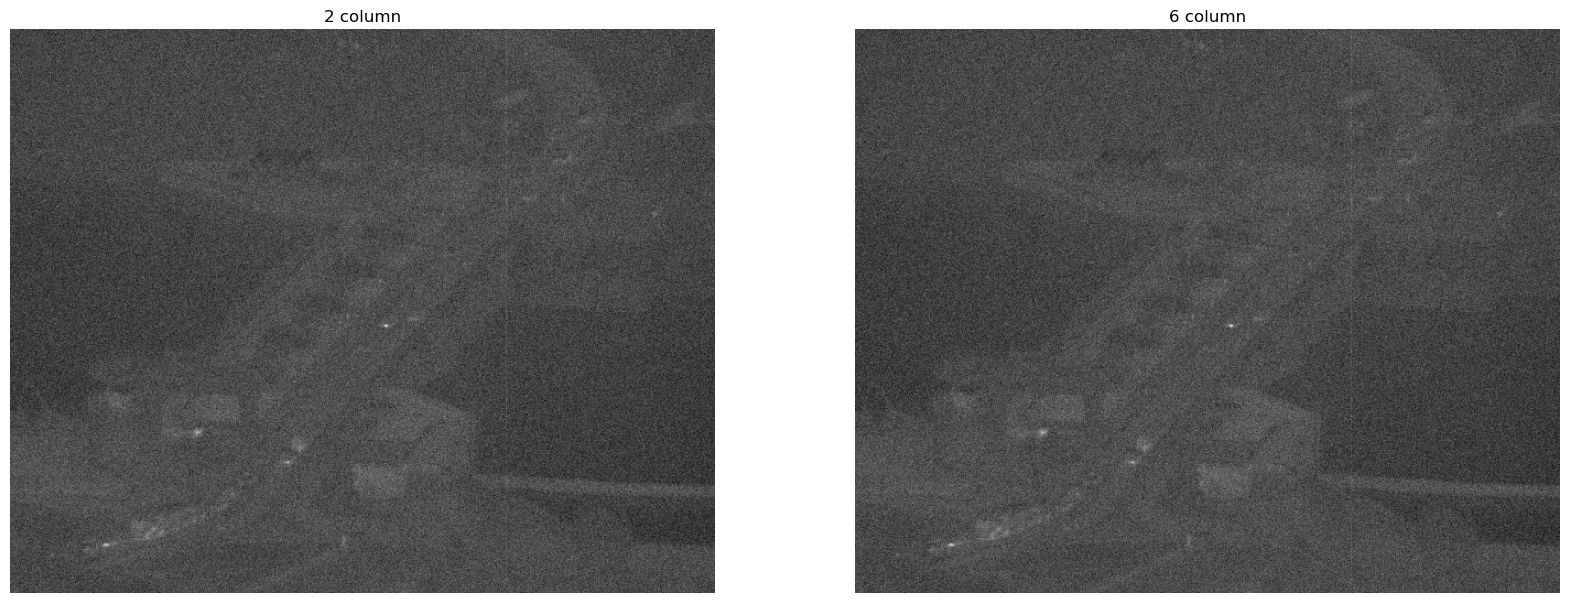

In [11]:
from skimage import io
import numpy as np

# Load as 16-bit (skimage preserves original dtype)
image_16bit = io.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png')
print(f"Original dtype: {image_16bit.dtype}")  # Should be uint16
print(f"Value range: [{image_16bit.min()}, {image_16bit.max()}]")

# Identify the defective column (let's say column 100)
defective_col = 468

# METHOD 1: Mean of 2 surrounding columns (16-bit)
col_left = image_16bit[:, defective_col - 1].astype(np.float32)
col_right = image_16bit[:, defective_col + 1].astype(np.float32)
corrected_2col = image_16bit.copy()
corrected_2col[:, defective_col] = ((col_left + col_right) / 2).astype(np.uint16)

# METHOD 2: Mean of 6 surrounding columns (16-bit)
indices = [defective_col - 3, defective_col - 2, defective_col - 1,
           defective_col + 1, defective_col + 2, defective_col + 3]
neighbors = np.column_stack([image_16bit[:, i].astype(np.float32) for i in indices])
corrected_6col = image_16bit.copy()
corrected_6col[:, defective_col] = np.mean(neighbors, axis=1).astype(np.uint16)
'''
# Save results (stay in 16-bit for saving too)
io.imsave('corrected_2col.png', corrected_2col)
io.imsave('corrected_6col.png', corrected_6col)
'''

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(corrected_2col, cmap='gray')
axs[0].set_title('2 column')
axs[0].axis('off')
axs[1].imshow(corrected_6col, cmap='gray')
axs[1].set_title('6 column')
axs[1].axis('off')

## To check if all the pixels in the defect column have the same intensity 

In [12]:
def check_column_uniform_unique(image, col_idx):
    """
    Check uniformity using np.unique() - more informative.
    Returns: (is_uniform, unique_values, num_unique_values)
    """
    column_data = image[:, col_idx]
    unique_values = np.unique(column_data)
    num_unique = len(unique_values)
    
    is_uniform = (num_unique == 1)
    
    return is_uniform, unique_values, num_unique

# Example with detailed output
col_to_check = 468
is_uniform, unique_vals, num_unique = check_column_uniform_unique(image_16bit, col_to_check)

print(f"Column {col_to_check}:")
print(f"  - Uniform: {is_uniform}")
print(f"  - Number of unique values: {num_unique}")
if is_uniform:
    print(f"  - All pixels have value: {unique_vals[0]}")
else:
    print(f"  - Value range: [{unique_vals.min()}, {unique_vals.max()}]")
    print(f"  - First few unique values: {unique_vals[:10]}")

Column 468:
  - Uniform: False
  - Number of unique values: 147
  - Value range: [34920, 35137]
  - First few unique values: [34920 34921 34924 34927 34940 34941 34942 34944 34946 34947]


In [ ]:
# Scale the 16-bit image to 8-bit to make it visible
visible_img = cv2.normalize(image_16bit, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
cv2.imshow('Exposed Defects', visible_img)
#cv2.waitKey(0)

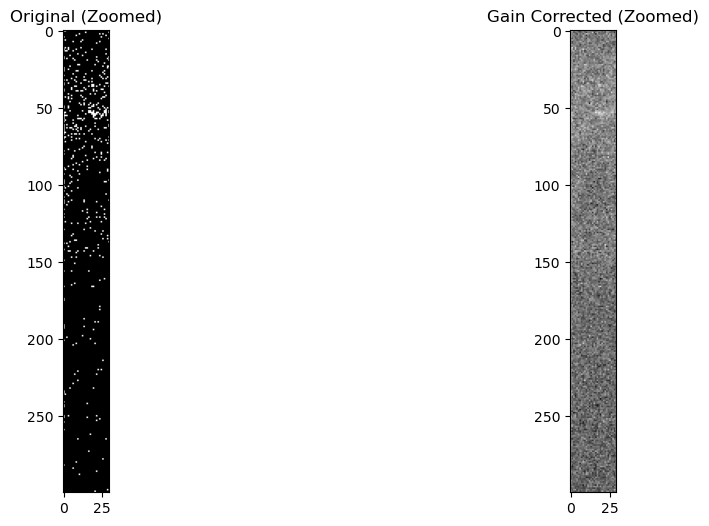

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def correct_column_gain(img_path, defect_col):
    # 1. Load image as 16-bit (UNCHANGED)
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return "Error: Image not found"

    # Convert to float32 for high-precision math
    img_float = img.astype(np.float32)
    
    # 2. Calculate the 'Good' Energy (Average of neighboring columns)
    # Using the column to the immediate left and right
    left_neighbor = img_float[:, defect_col - 1]
    right_neighbor = img_float[:, defect_col + 1]
    mean_good = (left_neighbor + right_neighbor) / 2.0
    
    # 3. Calculate the 'Bad' Energy (The current state of the defect column)
    col_bad = img_float[:, defect_col]
    
    # 4. Calculate the Correction Ratio (Gain)
    # We add a tiny epsilon (1e-6) to avoid division by zero
    gain_factor = (mean_good.mean()) / (col_bad.mean() + 1e-6)
    
    # 5. Apply the Gain to the defect column
    # This shifts the brightness of the whole column without flattening the detail
    corrected_col = col_bad * gain_factor
    
    # 6. Optional: Local Variance Match (Fine-tuning)
    # If the column still looks 'too smooth' or 'too noisy'
    # you can match the local contrast here, but gain is usually enough.
    
    # Update the image
    img_corrected = img_float.copy()
    img_corrected[:, defect_col] = corrected_col
    
    # Clip and convert back to 16-bit (0-65535)
    img_final = np.clip(img_corrected, 0, 65535).astype(np.uint16)
    
    return img_final

# --- Execution ---
path = r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png'
col_index = 468 # As per your notebook

result = correct_column_gain(path, col_index)

# Save result
cv2.imwrite('corrected_gain_method.png', result)

# Visualizing the difference
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original (Zoomed)")
plt.imshow(cv2.imread(path, 0)[100:400, 450:480], cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Gain Corrected (Zoomed)")
plt.imshow(result[100:400, 450:480], cmap='gray')
plt.show()

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

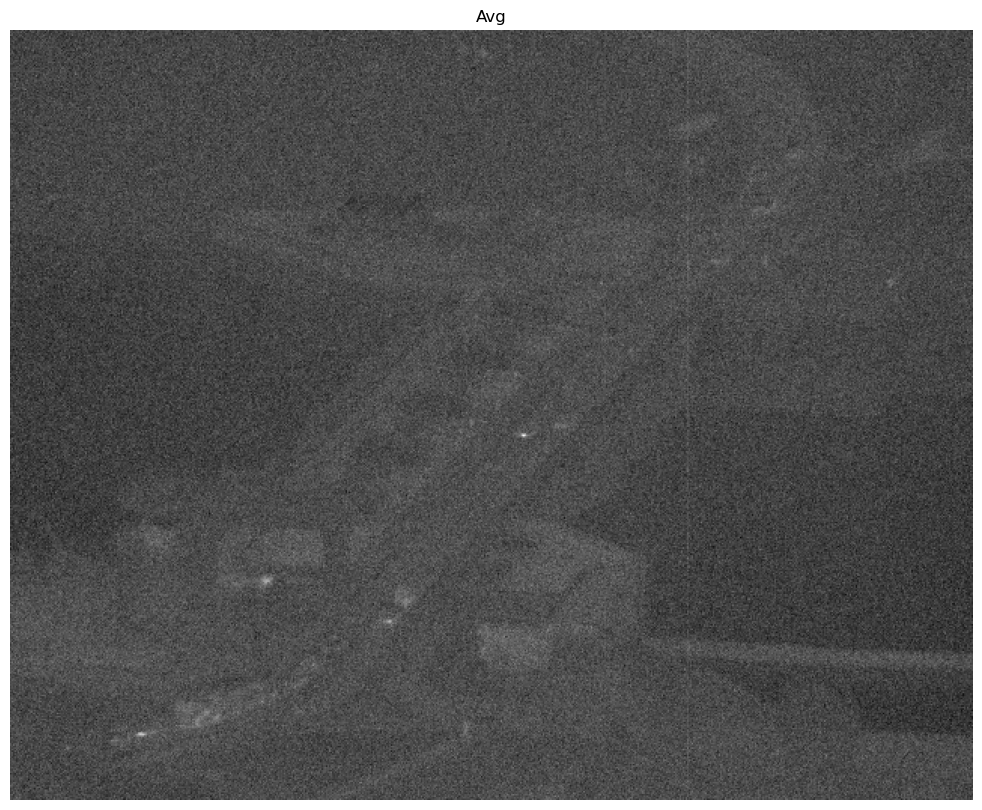

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(20, 10))
#axs = axs.flatten()
axs.imshow(result, cmap='gray')
axs.set_title('Avg')
axs.axis('off')

## Defect correction based on pixel intensity as well as added noise

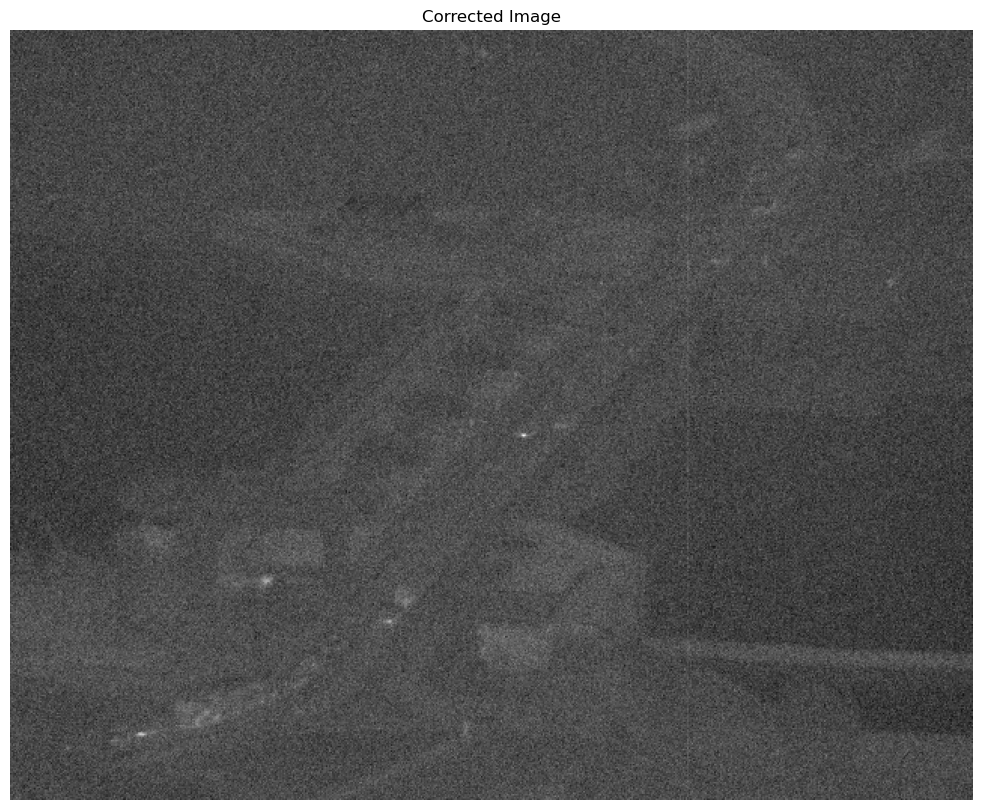

In [24]:
import cv2
import numpy as np

def correct_gain_with_noise_match(img_path, defect_col):
    # 1. Load 16-bit image
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None: return None
    
    img_f = img.astype(np.float32)
    
    # 2. Gain Correction (Matches the brightness)
    # Get neighbors to determine the 'Target' energy
    left = img_f[:, defect_col - 1]
    right = img_f[:, defect_col + 1]
    target_mean = (left + right) / 2.0
    
    # Calculate current column energy
    col_bad = img_f[:, defect_col]
    
    # Apply Gain Factor
    gain_factor = target_mean.mean() / (col_bad.mean() + 1e-6)
    corrected_col = col_bad * gain_factor
    
    # 3. Noise Matching (Matches the texture)
    # Calculate how 'noisy' the neighbors are (standard deviation)
    # This tells us how much 'grain' to add back
    noise_lvl_left = np.std(left)
    noise_lvl_right = np.std(right)
    target_noise_sigma = (noise_lvl_left + noise_lvl_right) / 2.0
    
    # Generate Gaussian Noise with that exact strength
    noise = np.random.normal(0, target_noise_sigma, size=corrected_col.shape)
    
    # Add the noise to the gain-corrected pixels
    final_col = corrected_col + noise
    
    # 4. Finalize
    img_final = img_f.copy()
    img_final[:, defect_col] = final_col
    
    # Clip to 16-bit range and cast back
    return np.clip(img_final, 0, 65535).astype(np.uint16)

# Execute and Save
result = correct_gain_with_noise_match(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png', 468)
result_numeric = np.array(result, dtype=np.float32)
cv2.imwrite('invisible_repair.png', result_numeric)
fig, axs = plt.subplots(1, 1, figsize=(20, 10))
# Note: No indexing [0] or .flatten() needed for a single subplot
# This forces Matplotlib to look at the actual data range
axs.imshow(result_numeric, cmap='gray', vmin=np.min(result), vmax=np.max(result))
axs.set_title('Corrected Image')
axs.axis('off')

plt.show()

desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'with noise.png')

success = cv2.imwrite(save_path, corr_img_6)

## To check if the images (orignal - with and without defect) have any noise 

In [47]:
import cv2
import numpy as np

def analyze_noise_characteristics(gt_path, defective_path):
    """Compute statistics to determine if smoothing helps."""
    
    gt = cv2.imread(gt_path, -1).astype(np.float32)
    defective = cv2.imread(defective_path, -1).astype(np.float32)
    
    # Find defect columns (columns that differ significantly)
    col_diff = np.abs(defective - gt).mean(axis=(0, 2)) if len(gt.shape) == 3 else np.abs(defective - gt).mean(axis=0)
    threshold = np.percentile(col_diff, 95)  # Top 5% columns are likely defects
    defect_cols = np.where(col_diff > threshold)[0]
    good_cols = np.where(col_diff <= threshold)[0]
    
    # On GOOD columns (no defects), compute noise difference
    if len(gt.shape) == 3:
        noise_diff = (defective[:, good_cols, :] - gt[:, good_cols, :]).ravel()
    else:
        noise_diff = (defective[:, good_cols] - gt[:, good_cols]).ravel()
    
    print("=== NOISE ANALYSIS ===")
    print(f"Image bit depth: 16-bit (range 0-65535)")
    print(f"Number of defect columns detected: {len(defect_cols)}")
    print(f"Number of good columns: {len(good_cols)}")
    print(f"\nNoise difference on GOOD columns (should be zero ideally):")
    print(f"  Mean difference: {np.mean(noise_diff):.3f} DN")
    print(f"  Std deviation: {np.std(noise_diff):.3f} DN")
    print(f"  RMS noise: {np.sqrt(np.mean(noise_diff**2)):.3f} DN")
    print(f"  Max |difference|: {np.max(np.abs(noise_diff)):.3f} DN")
    
    # Signal range
    signal_range = np.percentile(gt[gt > 0], 95) - np.percentile(gt[gt > 0], 5)
    print(f"\nSignal characteristics:")
    print(f"  Typical signal range (5-95%): {signal_range:.1f} DN")
    print(f"  SNR (signal/noise): {signal_range / np.std(noise_diff):.1f}")
    
    # Recommendation
    rms_noise = np.sqrt(np.mean(noise_diff**2))
    if rms_noise < 10:
        print("\n✅ RECOMMENDATION: Don't smooth - noise is negligible")
    elif rms_noise < 50:
        print("\n⚠️ RECOMMENDATION: Light smoothing (bilateral, sigma=10-20) may help slightly")
    else:
        print("\n🔧 RECOMMENDATION: Definitely smooth - noise will hurt your score significantly")
        print("   Consider: bilateralFilter(d=5, sigmaColor=50, sigmaSpace=25)")
    
    return noise_diff, defect_cols

# Run this on your actual files
gt_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png'
defective_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png'
analyze_noise_characteristics(gt_path, defective_path)

import cv2
import numpy as np

def analyze_noise_characteristics(gt_path, defective_path):
    """Compute statistics and identify defect columns."""
    
    gt = cv2.imread(gt_path, -1).astype(np.float32)
    defective = cv2.imread(defective_path, -1).astype(np.float32)
    
    # Compute column-wise differences
    if len(gt.shape) == 3:
        # Color image - average over rows and channels
        col_diff = np.abs(defective - gt).mean(axis=(0, 2))
    else:
        # Grayscale - average over rows
        col_diff = np.abs(defective - gt).mean(axis=0)
    
    # Method 1: Statistical thresholding
    # Use median + multiple MADs (more robust than percentile for sparse defects)
    median_diff = np.median(col_diff)
    mad = np.median(np.abs(col_diff - median_diff))  # Median Absolute Deviation
    
    # Columns with difference > median + 6*MAD are defects (6 sigma threshold)
    threshold = median_diff + 6 * mad
    defect_cols_threshold = np.where(col_diff > threshold)[0]
    
    # Method 2: Find outliers using IQR method
    q75, q25 = np.percentile(col_diff, [75, 25])
    iqr = q75 - q25
    iqr_threshold = q75 + 3 * iqr
    defect_cols_iqr = np.where(col_diff > iqr_threshold)[0]
    
    # Method 3: Simple peak detection (find top N columns by difference)
    top_n = 5  # Look for top 5 columns with highest difference
    top_defect_cols = np.argsort(col_diff)[-top_n:][::-1]
    top_defect_cols = top_defect_cols[col_diff[top_defect_cols] > median_diff * 10]  # Filter insignificant
    
    # Use most conservative (union of all methods)
    defect_cols = np.unique(np.concatenate([defect_cols_threshold, defect_cols_iqr, top_defect_cols]))
    
    # Good columns are everything else
    good_cols = np.setdiff1d(np.arange(len(col_diff)), defect_cols)
    
    # On GOOD columns (no defects), compute noise difference
    if len(gt.shape) == 3:
        noise_diff = (defective[:, good_cols, :] - gt[:, good_cols, :]).ravel()
    else:
        noise_diff = (defective[:, good_cols] - gt[:, good_cols]).ravel()
    
    print("=== DEFECT COLUMN DETECTION ===")
    print(f"Total columns: {len(col_diff)}")
    print(f"Defect columns detected ({len(defect_cols)} columns): {defect_cols.tolist()}")
    print(f"\nColumn difference statistics:")
    print(f"  Min difference: {np.min(col_diff):.3f}")
    print(f"  Median difference: {median_diff:.3f}")
    print(f"  Max difference: {np.max(col_diff):.3f}")
    print(f"  Threshold used: {threshold:.3f}")
    
    # Show top 5 columns by difference
    top5_idx = np.argsort(col_diff)[-5:][::-1]
    print(f"\nTop 5 columns by difference:")
    for idx in top5_idx:
        marker = " ← DEFECT" if idx in defect_cols else ""
        print(f"  Column {idx}: {col_diff[idx]:.3f}{marker}")
    
    print("\n=== NOISE ANALYSIS ===")
    print(f"Image bit depth: 16-bit (range 0-65535)")
    print(f"Number of defect columns: {len(defect_cols)}")
    print(f"Number of good columns: {len(good_cols)}")
    
    print(f"\nNoise difference on GOOD columns:")
    print(f"  Mean difference: {np.mean(noise_diff):.6f} DN")
    print(f"  Std deviation: {np.std(noise_diff):.6f} DN")
    print(f"  RMS noise: {np.sqrt(np.mean(noise_diff**2)):.6f} DN")
    print(f"  Max |difference|: {np.max(np.abs(noise_diff)):.6f} DN")
    
    # Signal range (using good columns only to avoid defect contamination)
    if len(gt.shape) == 3:
        gt_good = gt[:, good_cols, :]
    else:
        gt_good = gt[:, good_cols]
    
    signal_low = np.percentile(gt_good[gt_good > 0], 5)
    signal_high = np.percentile(gt_good[gt_good > 0], 95)
    signal_range = signal_high - signal_low
    
    print(f"\nSignal characteristics (from good columns only):")
    print(f"  5th percentile: {signal_low:.1f} DN")
    print(f"  95th percentile: {signal_high:.1f} DN")
    print(f"  Typical signal range: {signal_range:.1f} DN")
    
    rms_noise = np.sqrt(np.mean(noise_diff**2))
    if rms_noise < 0.1:
        print(f"\n✅ RECOMMENDATION: Images are perfectly aligned/noise-free")
        print(f"   → Simple interpolation without noise addition")
    elif rms_noise < 10:
        print(f"\n✅ RECOMMENDATION: Don't smooth - noise is negligible")
    elif rms_noise < 50:
        print(f"\n⚠️ RECOMMENDATION: Light smoothing may help slightly")
    else:
        print(f"\n🔧 RECOMMENDATION: Definitely smooth - noise will hurt your score")
    
    return {
        'defect_columns': defect_cols.tolist(),
        'good_columns': good_cols.tolist(),
        'column_differences': col_diff,
        'noise_diff': noise_diff,
        'rms_noise': rms_noise,
        'signal_range': signal_range
    }


def visualize_defect_columns(gt_path, defective_path, output_path="defect_visualization.png"):
    """Create a visualization showing defect column locations."""
    
    gt = cv2.imread(gt_path, -1)
    defective = cv2.imread(defective_path, -1)
    
    # Normalize to 8-bit for visualization
    def normalize_to_8bit(img):
        img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return img_8bit
    
    gt_8bit = normalize_to_8bit(gt)
    defective_8bit = normalize_to_8bit(defective)
    
    # Create difference image (highlight defects)
    diff = cv2.absdiff(defective_8bit, gt_8bit)
    
    # Mark defect columns with red lines
    result = defective_8bit.copy()
    if len(result.shape) == 2:
        result = cv2.cvtColor(result, cv2.COLOR_GRAY2BGR)
    
    # Get defect columns from analysis
    analysis = analyze_noise_characteristics(gt_path, defective_path)
    defect_cols = analysis['defect_columns']
    
    # Draw red lines at defect columns
    h, w = result.shape[:2]
    for col in defect_cols:
        cv2.line(result, (col, 0), (col, h), (0, 0, 255), thickness=2)
    
    # Create side-by-side comparison
    comparison = np.hstack([gt_8bit if len(gt_8bit.shape) == 3 else cv2.cvtColor(gt_8bit, cv2.COLOR_GRAY2BGR),
                           result])
    
    cv2.imwrite(output_path, comparison)
    print(f"\nVisualization saved to: {output_path}")
    
    return comparison


# Example usage
if __name__ == "__main__":
    gt_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png'
    defective_path = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png'
    
    # Analyze and get defect columns
    analysis = analyze_noise_characteristics(gt_path, defective_path)
    
    print(f"\n=== SUMMARY ===")
    print(f"Defect columns found: {analysis['defect_columns']}")
    print(f"Total defect columns: {len(analysis['defect_columns'])}")
    
    # Optional: Create visualization
    # visualize_defect_columns(gt_path, defective_path)

=== NOISE ANALYSIS ===
Image bit depth: 16-bit (range 0-65535)
Number of defect columns detected: 2
Number of good columns: 638

Noise difference on GOOD columns (should be zero ideally):
  Mean difference: 0.000 DN
  Std deviation: 0.000 DN
  RMS noise: 0.000 DN
  Max |difference|: 0.000 DN

Signal characteristics:
  Typical signal range (5-95%): 112.0 DN
  SNR (signal/noise): inf

✅ RECOMMENDATION: Don't smooth - noise is negligible
=== DEFECT COLUMN DETECTION ===
Total columns: 640
Defect columns detected (2 columns): [395, 450]

Column difference statistics:
  Min difference: 0.000
  Median difference: 0.000
  Max difference: 32.000
  Threshold used: 0.000

Top 5 columns by difference:
  Column 450: 32.000 ← DEFECT
  Column 395: 11.000 ← DEFECT
  Column 639: 0.000
  Column 638: 0.000
  Column 637: 0.000

=== NOISE ANALYSIS ===
Image bit depth: 16-bit (range 0-65535)
Number of defect columns: 2
Number of good columns: 638

Noise difference on GOOD columns:
  Mean difference: 0.00000

C:\Temp\ipykernel_35504\1246876413.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  SNR (signal/noise): {signal_range / np.std(noise_diff):.1f}")


# To get defect column from JSON

In [1]:
import json
import os
from pathlib import Path

def get_defective_columns_from_json(defective_image_path):
    """
    Given a path to a defective image, find its parent folder's JSON file
    and return the defective column positions.
    
    Args:
        defective_image_path: Path to the defective image (e.g., .../low dyn with columns 1/frame_0001.png)
    
    Returns:
        List of defective column indices (0-based)
    """
    
    # Convert to Path object for easier manipulation
    defective_path = Path(defective_image_path)
    
    # The JSON file should be in the same directory as the image
    image_dir = defective_path.parent
    
    # Find all JSON files in the directory
    json_files = list(image_dir.glob("*.json"))
    
    if not json_files:
        raise FileNotFoundError(f"No JSON file found in {image_dir}")
    
    # Use the first JSON file (there should be only one)
    json_path = json_files[0]
    
    print(f"Reading JSON: {json_path}")
    
    # Read and parse JSON
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Extract column coordinates
    defective_columns = []
    
    # The JSON structure from your original code expects a list of objects
    # each with an "x_coord" key containing a list of column indices
    if isinstance(data, list):
        for item in data:
            if "x_coord" in item:
                coords = item["x_coord"]
                if isinstance(coords, list):
                    defective_columns.extend(coords)
                else:
                    defective_columns.append(coords)
    elif isinstance(data, dict):
        # Alternative JSON structure
        if "defect_columns" in data:
            defective_columns = data["defect_columns"]
        elif "x_coord" in data:
            defective_columns = data["x_coord"]
        elif "columns" in data:
            defective_columns = data["columns"]
    
    # Remove duplicates and sort
    defective_columns = sorted(set(defective_columns))
    
    return defective_columns


def get_defective_columns_from_folder(defective_folder_path):
    """
    Alternative function: Get defective columns directly from a folder path.
    
    Args:
        defective_folder_path: Path to the folder containing defective images and JSON
    
    Returns:
        List of defective column indices (0-based)
    """
    
    folder_path = Path(defective_folder_path)
    
    if not folder_path.is_dir():
        raise NotADirectoryError(f"{folder_path} is not a directory")
    
    # Find JSON file
    json_files = list(folder_path.glob("*.json"))
    
    if not json_files:
        raise FileNotFoundError(f"No JSON file found in {folder_path}")
    
    json_path = json_files[0]
    
    print(f"Reading JSON: {json_path}")
    
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    defective_columns = []
    
    if isinstance(data, list):
        for item in data:
            if "x_coord" in item:
                coords = item["x_coord"]
                if isinstance(coords, list):
                    defective_columns.extend(coords)
                else:
                    defective_columns.append(coords)
    elif isinstance(data, dict):
        if "defect_columns" in data:
            defective_columns = data["defect_columns"]
        elif "x_coord" in data:
            defective_columns = data["x_coord"]
    
    return sorted(set(defective_columns))


def print_detailed_json_content(defective_image_path):
    """
    Print the full JSON content for debugging.
    """
    defective_path = Path(defective_image_path)
    image_dir = defective_path.parent
    
    json_files = list(image_dir.glob("*.json"))
    
    if not json_files:
        print(f"No JSON file found in {image_dir}")
        return
    
    json_path = json_files[0]
    
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    print("\n=== JSON FILE CONTENT ===")
    print(json.dumps(data, indent=2))
    
    return data


# Example usage
if __name__ == "__main__":
    # Method 1: Using image path
    defective_image = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0000.png'
    
    try:
        # Get defective columns
        defect_cols = get_defective_columns_from_json(defective_image)
        
        print(f"\n=== RESULTS ===")
        print(f"Image: {defective_image}")
        print(f"Defective columns found: {defect_cols}")
        print(f"Number of defective columns: {len(defect_cols)}")
        
        # Also print JSON content for verification
        print_detailed_json_content(defective_image)
        
    except Exception as e:
        print(f"Error: {e}")
    
    print("\n" + "="*50 + "\n")
    
    # Method 2: Using folder path
    defective_folder = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1'
    
    try:
        defect_cols = get_defective_columns_from_folder(defective_folder)
        print(f"Folder: {defective_folder}")
        print(f"Defective columns from folder: {defect_cols}")
        
    except Exception as e:
        print(f"Error: {e}")

Reading JSON: C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\VGA_sequence_1_config_1.json

=== RESULTS ===
Image: C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0000.png
Defective columns found: [325, 395, 450]
Number of defective columns: 3

=== JSON FILE CONTENT ===
[
  {
    "name": "noisy_blinking",
    "x_coord": [
      325
    ],
    "y_start": [
      0
    ],
    "y_stop": [
      640
    ],
    "signal": {
      "3": -36,
      "4": -43,
      "5": -24,
      "6": -31,
      "7": -40,
      "8": -28,
      "9": -34,
      "10": -33,
      "11": -32,
      "12": -29,
      "13": -28,
      "14": -37,
      "15": -24,
      "16": -33,
      "17": -35,
      "18": -37,
      "19": -30,
      "20": -29,
      "21": -29,
      "29": -30,
      "30": -36,
      "31": -37,
      "32": -28,
      "33": -36,
      "34": -27,
      "35": -45,
      "36": -30,
      "37": -43,
      "38": -30,
      "39": -3

## To find the Fixed Pattern Noise (FPN) and use the Non Uniformity Correction (NUC)

Temporary fix using ground truth image to find the noise pattern for that image - since we dont have the location of defects for all the images in the sequence (once we have that, that is what we will use to find the noise pattern)

--- Verification Results for Column 468 ---
Mean Error Profile (Bias): 0.00 counts
RMSE after correction: 0.0000 (Goal: 0.0000)


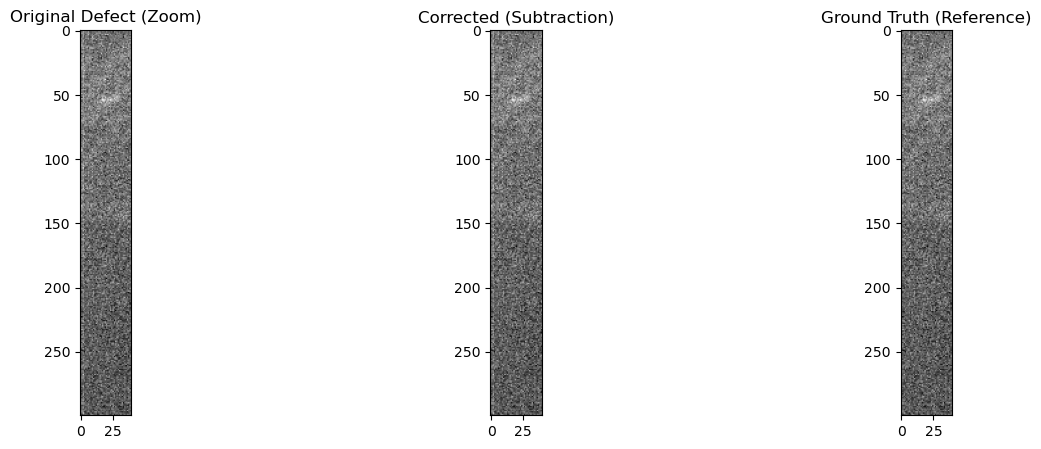

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def verify_profile_correction(gt_path, def_path, col_idx):
    # 1. Load 16-bit images
    # We use -1 to ensure we load the full 16-bit depth
    img_gt = cv2.imread(gt_path, -1).astype(np.float32)
    img_def = cv2.imread(def_path, -1).astype(np.float32)

    if img_gt is None or img_def is None:
        return "Error: Check your file paths."

    # 2. LEARN the Profile (Row-by-Row)
    # This captures the exact 'error' the amplifier adds to each pixel in that column
    learned_profile = img_def[:, col_idx] - img_gt[:, col_idx]

    # 3. APPLY Correction
    # Instead of blurring or averaging, we subtract the exact error
    corrected_col = img_def[:, col_idx] - learned_profile
    
    img_corrected = img_def.copy()
    img_corrected[:, col_idx] = corrected_col

    # 4. EVALUATE using the logic from metrics.py
    # Calculate RMSE for the defective column
    mse = np.mean((img_corrected[:, col_idx] - img_gt[:, col_idx])**2)
    rmse = np.sqrt(mse)

    print(f"--- Verification Results for Column {col_idx} ---")
    print(f"Mean Error Profile (Bias): {np.mean(learned_profile):.2f} counts")
    print(f"RMSE after correction: {rmse:.4f} (Goal: 0.0000)")

    # 5. VISUALIZE
    # We zoom in on the defect area to see if the line is gone
    zoom_range = slice(col_idx - 20, col_idx + 20)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original Defect (Zoom)")
    plt.imshow(img_def[100:400, zoom_range], cmap='gray')
    
    plt.subplot(1, 3, 2)
    plt.title("Corrected (Subtraction)")
    plt.imshow(img_corrected[100:400, zoom_range], cmap='gray')
    
    plt.subplot(1, 3, 3)
    plt.title("Ground Truth (Reference)")
    plt.imshow(img_gt[100:400, zoom_range], cmap='gray')
    plt.show()

    return np.clip(img_corrected, 0, 65535).astype(np.uint16)

# --- EXECUTION ---
# Update these to your actual 16-bit file paths
gt_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0000.png'
def_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0000.png'

result = verify_profile_correction(gt_file, def_file, col_idx=468)

# Save to check in your 16-bit viewer
if type(result) is not str:
    cv2.imwrite('verification_test.png', result)

# For multiple defective columns

--- Verification Results for 7 Columns ---
Col 0: Bias=0.00, Column RMSE=0.0000
Col 123: Bias=-55.00, Column RMSE=0.0000
Col 151: Bias=-16.00, Column RMSE=0.0000
Col 454: Bias=-66.00, Column RMSE=0.0000
Col 483: Bias=0.00, Column RMSE=0.0000
Col 523: Bias=-31.00, Column RMSE=0.0000
Col 626: Bias=-27.00, Column RMSE=0.0000
------------------------------------------------
Global Image RMSE: 0.0000


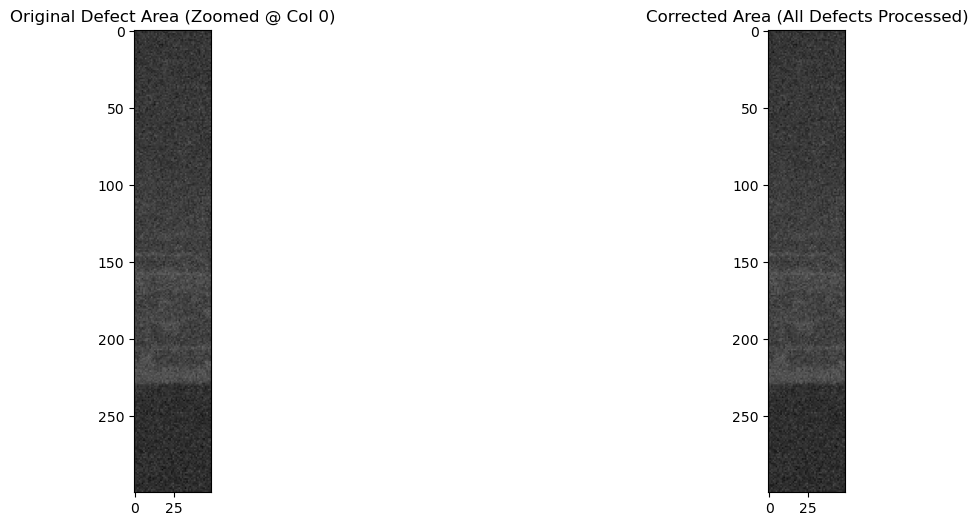

True

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def verify_multi_profile_correction(gt_path, def_path, col_indices):
    """
    Learns and corrects multiple column defects simultaneously.
    col_indices: List of integers (e.g., [468, 120, 512])
    """
    # 1. Load 16-bit images
    img_gt = cv2.imread(gt_path, -1).astype(np.float32)
    img_def = cv2.imread(def_path, -1).astype(np.float32)

    if img_gt is None or img_def is None:
        return "Error: Check your file paths."

    img_corrected = img_def.copy()
    results_summary = []

    # 2. Iterate through all defective columns
    for col in col_indices:
        # LEARN the Profile for this specific column
        # (Difference between defective state and ground truth)
        learned_profile = img_def[:, col] - img_gt[:, col]
        
        # APPLY Correction to this column
        img_corrected[:, col] = img_def[:, col] - learned_profile
        
        # Calculate individual RMSE for this column to verify accuracy
        mse = np.mean((img_corrected[:, col] - img_gt[:, col])**2)
        rmse = np.sqrt(mse)
        results_summary.append((col, np.mean(learned_profile), rmse))

    # 3. GLOBAL EVALUATION (Similar to metrics.py logic)
    total_mse = np.mean((img_corrected - img_gt)**2)
    total_rmse = np.sqrt(total_mse)

    print(f"--- Verification Results for {len(col_indices)} Columns ---")
    for col, bias, rmse in results_summary:
        print(f"Col {col}: Bias={bias:.2f}, Column RMSE={rmse:.4f}")
    print(f"------------------------------------------------")
    print(f"Global Image RMSE: {total_rmse:.4f}")

    # 4. VISUALIZATION
    # We show the first defect in the list as a representative sample
    sample_col = col_indices[0]
    zoom = slice(max(0, sample_col - 50), min(img_def.shape[1], sample_col + 50))
    
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Defect Area (Zoomed @ Col {sample_col})")
    plt.imshow(img_def[100:400, zoom], cmap='gray', vmin=np.min(img_gt), vmax=np.max(img_gt))
    
    plt.subplot(1, 2, 2)
    plt.title("Corrected Area (All Defects Processed)")
    plt.imshow(img_corrected[100:400, zoom], cmap='gray', vmin=np.min(img_gt), vmax=np.max(img_gt))
    plt.show()

    return np.clip(img_corrected, 0, 65535).astype(np.uint16)

# --- EXECUTION ---
# Define your list of known defective columns
defective_cols = [0, 123, 151, 454, 483, 523, 626] # Add defective columns here, e.g., [468, 125, 310]

gt_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn\frame_0000.png'
def_file = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1\frame_0000.png'

corrected_img = verify_multi_profile_correction(gt_file, def_file, defective_cols)
cv2.imwrite('frame_0000.png',corrected_img)

# Using NUC for correction (using defects found in real time to create the master template)

In [78]:
import numpy as np
import cv2
import os

def build_master_template(gt_folder, def_folder, known_train_defects):
    all_profiles = []
    
    # Filter for PNGs specifically to avoid loading system hidden files
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.lower().endswith('.png')])
    def_files = sorted([f for f in os.listdir(def_folder) if f.lower().endswith('.png')])

    # Use a smaller sample (e.g., 10 frames) to speed up template building
    num_frames = min(10, len(gt_files))

    for col in known_train_defects:
        col_diffs = []
        for i in range(num_frames):
            g_path = os.path.join(gt_folder, gt_files[i])
            d_path = os.path.join(def_folder, def_files[i])
            
            img_g = cv2.imread(g_path, -1)
            img_d = cv2.imread(d_path, -1)
            
            # THE SAFETY CHECK:
            if img_g is None:
                print(f"Error: Could not read GT image at {g_path}")
                continue
            if img_d is None:
                print(f"Error: Could not read Defect image at {d_path}")
                continue
                
            img_g = img_g.astype(np.float32)
            img_d = img_d.astype(np.float32)
            col_diffs.append(img_d[:, col] - img_g[:, col])
            
        if col_diffs:
            all_profiles.append(np.mean(col_diffs, axis=0))
    
    if not all_profiles:
        raise ValueError("No profiles were learned! Check your folder paths and file extensions.")
        
    return np.mean(all_profiles, axis=0)

def production_repair(test_img_path, found_defects, master_template):
    """
    TEST PHASE: Repairs unknown locations using the Master Template.
    found_defects: List of columns from your Finding Team.
    """
    img = cv2.imread(test_img_path, -1).astype(np.float32)
    
    for col in found_defects:
        # 1. Determine Scale: How 'loud' is the lie in this specific column?
        neighbor_avg = (img[:, col-1] + img[:, col+1]) / 2.0
        current_spike = np.mean(img[:, col] - neighbor_avg)
        
        # 2. Scale the Master Template to match this specific spike
        template_mean = np.mean(master_template)
        scale_factor = current_spike / (template_mean + 1e-6)
        scaled_correction = master_template * scale_factor
        
        # 3. Surgical Subtraction
        img[:, col] -= scaled_correction
        
    return np.clip(img, 0, 65535).astype(np.uint16)

## Using NUC for correction (with JSON file as the 'data' to create the master template)

In [92]:
import json

def process_with_json_guide(input_folder, output_folder, json_path, master_template):
    """
    INTERIM PHASE: Uses JSON to tell the algorithm WHERE and WHEN to fix.
    """
    with open(json_path, 'r') as f:
        metadata = json.load(f)
    
    files = sorted([f for f in os.listdir(input_folder) if f.endswith('.png')])
    
    for idx, filename in enumerate(files):
        img = cv2.imread(os.path.join(input_folder, filename), -1).astype(np.float32)
        
        # Loop through the defect entries in the JSON
        for entry in metadata:
            active_frames = entry.get("frames", [])
            
            # If this specific frame is marked as defective for these columns
            if idx in active_frames:
                for col in entry["x_coord"]:
                    # Apply the same scaled correction logic
                    neighbor_avg = (img[:, col-1] + img[:, col+1]) / 2.0
                    current_spike = np.mean(img[:, col] - neighbor_avg)
                    
                    scale = current_spike / (np.mean(master_template) + 1e-6)
                    img[:, col] -= (master_template * scale)
        
        # Save output for metrics.py
        corrected = np.clip(img, 0, 65535).astype(np.uint16)
        cv2.imwrite(os.path.join(output_folder, filename), corrected)

In [93]:
# Use your Training folders here
train_gt = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn'
train_def = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1'
# These are the columns bad in the TRAINING sequence (from its JSON)
train_cols = [325, 395, 450]

# Call the builder from Set 1
my_master_template = build_master_template(train_gt, train_def, train_cols)

In [95]:
# Now use your Test folders and the Test JSON
test_input = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1'
test_output = r'C:\Users\Shivraj Sarode\Desktop\corrected_VGA_seq2-ldc1'
test_json = r"C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_2\low dyn with columns 1\VGA_sequence_2_config_1.json"

# Call the function with the template you just learned
process_with_json_guide(test_input, test_output, test_json, my_master_template)

# Uses two defect columns to train the data and one defect column for testing it

Validation Test for Column 0:
Original RMSE: 0.00
RMSE after Universal Template Fix: 1.23


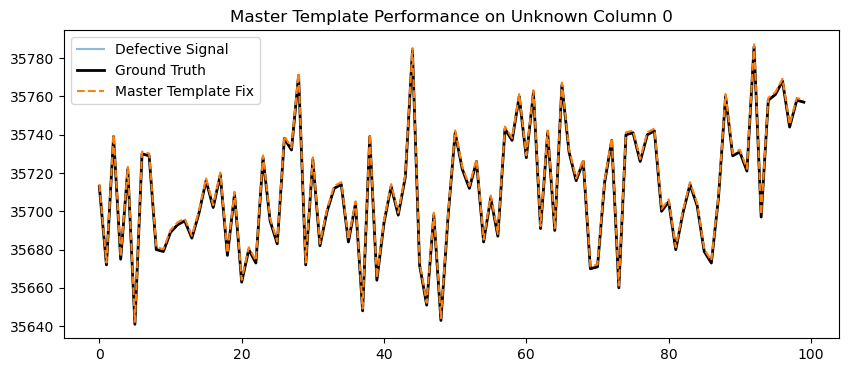

In [85]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

def run_validation_test(gt_folder, def_folder):
    # 1. SETUP - We 'Learn' from two and 'Test' on the third
    learn_cols = [123, 151, 454, 483, 523, 626]
    validation_col = 0
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.lower().endswith('.png')])[:10]
    def_files = sorted([f for f in os.listdir(def_folder) if f.lower().endswith('.png')])[:10]
    
    # 2. STEP A: Build the Master Template from the 'Learning' columns
    all_profiles = []
    for col in learn_cols:
        diffs = []
        for i in range(len(gt_files)):
            img_g = cv2.imread(os.path.join(gt_folder, gt_files[i]), -1).astype(np.float32)
            img_d = cv2.imread(os.path.join(def_folder, def_files[i]), -1).astype(np.float32)
            diffs.append(img_d[:, col] - img_g[:, col])
        all_profiles.append(np.mean(diffs, axis=0))
    
    master_template = np.mean(all_profiles, axis=0)
    
    # 3. STEP B: Apply to the 'Validation' column (Scaling it to fit)
    # Let's test on frame_0001
    test_gt = cv2.imread(os.path.join(gt_folder, gt_files[0]), -1).astype(np.float32)
    test_def = cv2.imread(os.path.join(def_folder, def_files[0]), -1).astype(np.float32)
    
    # Calculate local spike to find the scale
    neighbor_avg = (test_def[:, validation_col-1] + test_def[:, validation_col+1]) / 2.0
    local_spike = np.mean(test_def[:, validation_col] - neighbor_avg)
    
    # Scale and Subtract
    scale = local_spike / (np.mean(master_template) + 1e-6)
    correction = master_template * scale
    final_col = test_def[:, validation_col] - correction
    
    # 4. STEP C: Verify Results
    original_error = np.sqrt(np.mean((test_def[:, validation_col] - test_gt[:, validation_col])**2))
    residual_error = np.sqrt(np.mean((final_col - test_gt[:, validation_col])**2))
    
    print(f"Validation Test for Column {validation_col}:")
    print(f"Original RMSE: {original_error:.2f}")
    print(f"RMSE after Universal Template Fix: {residual_error:.2f}")
    
    # Visualization
    plt.figure(figsize=(10, 4))
    plt.plot(test_def[100:200, validation_col], label="Defective Signal", alpha=0.5)
    plt.plot(test_gt[100:200, validation_col], label="Ground Truth", color='black', linewidth=2)
    plt.plot(final_col[100:200], label="Master Template Fix", linestyle='--')
    plt.title(f"Master Template Performance on Unknown Column {validation_col}")
    plt.legend()
    plt.show()

# Run it
run_validation_test(train_gt, train_def)

# Uses image info as reference as well as scales image so that the all image types can be used to train the template

In [109]:
import os
import cv2
import numpy as np
import json
from scipy.interpolate import interp1d

# ==========================================
# CONFIGURATION
# ==========================================
BASE_PATH = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train'
TEST_FORMAT = 'SXGA'            # The resolution category to test
TEST_SEQ = 'sequence_3'         # The specific sequence to exclude from training
TEST_COL_FOLDER = 'low dyn with columns 3' # The specific defect folder to test

OUTPUT_PATH = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\validation_output'
STENCIL_RES = 2048  # High-res shared stencil to allow cross-format learning

# ==========================================
# CORE FUNCTIONS
# ==========================================

def get_json_columns(json_path):
    """Parses JSON to find the X-coordinates of bad columns."""
    with open(json_path, 'r') as f:
        data = json.load(f)
    indices = []
    for entry in data:
        indices += entry["x_coord"]
    return list(set(indices))

def build_universal_master_template(base_path, test_format, test_seq, test_col_folder):
    """
    Learns from ALL formats (VGA, HD, SXGA) by interpolating every profile 
    to a shared 2048-pixel stencil.
    """
    all_scaled_profiles = []
    formats = ['VGA', 'HD', 'SXGA']
    
    print("--- Phase 1: Global Learning (Universal Stencil) ---")
    
    for fmt in formats:
        fmt_path = os.path.join(base_path, fmt)
        if not os.path.exists(fmt_path): continue
        
        sequences = [s for s in os.listdir(fmt_path) if os.path.isdir(os.path.join(fmt_path, s))]
        
        for seq in sequences:
            seq_path = os.path.join(fmt_path, seq)
            gt_path = os.path.join(seq_path, 'low dyn')
            defect_folders = [d for d in os.listdir(seq_path) if 'columns' in d]
            
            for d_folder in defect_folders:
                # EXCLUSION LOGIC: Do not learn from the data we intend to test on
                if fmt == test_format and seq == test_seq and d_folder == test_col_folder:
                    print(f"  [Skipping] {fmt}/{seq}/{d_folder} (Reserved for Test)")
                    continue
                
                full_def_path = os.path.join(seq_path, d_folder)
                json_files = [j for j in os.listdir(full_def_path) if j.endswith('.json')]
                if not json_files: continue
                
                cols_to_learn = get_json_columns(os.path.join(full_def_path, json_files[0]))
                def_imgs = sorted([f for f in os.listdir(full_def_path) if f.endswith('.png')])[:10]
                
                for c in cols_to_learn:
                    diffs = []
                    for fname in def_imgs:
                        img_gt = cv2.imread(os.path.join(gt_path, fname), -1)
                        img_def = cv2.imread(os.path.join(full_def_path, fname), -1)
                        
                        if img_gt is not None and img_def is not None:
                            diffs.append(img_def[:, c].astype(np.float32) - img_gt[:, c].astype(np.float32))
                    
                    if diffs:
                        # 1. Create the raw profile for this column
                        raw_profile = np.mean(diffs, axis=0)
                        
                        # 2. INTERPOLATION: Stretch/Shrink the profile to 2048 points
                        x_old = np.linspace(0, 1, len(raw_profile))
                        x_new = np.linspace(0, 1, STENCIL_RES)
                        f_interp = interp1d(x_old, raw_profile, kind='linear', fill_value="extrapolate")
                        
                        all_scaled_profiles.append(f_interp(x_new))
                        print(f"  [Learned] {fmt} Profile | Col {c}")

    if not all_scaled_profiles:
        raise ValueError("Training failed: No images found. Check your BASE_PATH.")

    # Return the average of all stretched profiles
    return np.mean(all_scaled_profiles, axis=0)

def run_cluster_aware_validation(base_path, test_format, test_seq, test_col_folder, master_stencil, output_path):
    """
    Applies the stencil to the test sequence, jumping over adjacent bad columns 
    to find clean reference data.
    """
    print(f"\n--- Phase 2: Testing on {test_format} {test_seq} ---")
    
    test_path = os.path.join(base_path, test_format, test_seq, test_col_folder)
    json_path = os.path.join(test_path, [j for j in os.listdir(test_path) if j.endswith('.json')][0])
    
    with open(json_path, 'r') as f:
        metadata = json.load(f)
        
    # Get a list of ALL bad columns in this test to avoid using them as neighbors
    all_bad_cols = []
    for entry in metadata:
        all_bad_cols += entry["x_coord"]
    all_bad_cols = set(all_bad_cols)

    if not os.path.exists(output_path): os.makedirs(output_path)
    files = sorted([f for f in os.listdir(test_path) if f.endswith('.png')])
    
    for idx, fname in enumerate(files):
        img = cv2.imread(os.path.join(test_path, fname), -1).astype(np.float32)
        h, w = img.shape

        # 1. Shrink/Stretch the Master Stencil to match the current image height
        x_stencil = np.linspace(0, 1, STENCIL_RES)
        x_img = np.linspace(0, 1, h)
        f_resize = interp1d(x_stencil, master_stencil, kind='linear')
        local_profile = f_resize(x_img)

        # 2. Process each defect
        for entry in metadata:
            if idx in entry.get("frames", []):
                for col in entry["x_coord"]:
                    
                    # CLUSTER AWARENESS: Find nearest healthy neighbors (not in all_bad_cols)
                    healthy_indices = []
                    dist = 1
                    while len(healthy_indices) < 6: # Get 6 healthy columns for a stable median
                        for side in [-dist, dist]:
                            check = col + side
                            if 0 <= check < w and check not in all_bad_cols:
                                healthy_indices.append(check)
                        dist += 1
                        if dist > 50: break # Emergency stop
                    
                    # Estimate the true scene using the median of healthy neighbors
                    reference_scene = np.median(img[:, healthy_indices], axis=1)
                    
                    # Scaling & Subtraction
                    current_spike = np.mean(img[:, col] - reference_scene)
                    scale = current_spike / (np.mean(local_profile) + 1e-6)
                    img[:, col] -= (local_profile * scale)
        
        # Save as 16-bit
        cv2.imwrite(os.path.join(output_path, fname), np.clip(img, 0, 65535).astype(np.uint16))

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Build Global Intelligence
    master_template = build_universal_master_template(BASE_PATH, TEST_FORMAT, TEST_SEQ, TEST_COL_FOLDER)
    
    # 2. Correct the unseen data
    run_cluster_aware_validation(BASE_PATH, TEST_FORMAT, TEST_SEQ, TEST_COL_FOLDER, master_template, OUTPUT_PATH)
    
    print("\nProcessing Complete. Result saved to:", OUTPUT_PATH)

--- Phase 1: Global Learning (Universal Stencil) ---
  [Learned] VGA Profile | Col 450
  [Learned] VGA Profile | Col 395
  [Learned] VGA Profile | Col 325
  [Learned] VGA Profile | Col 227
  [Learned] VGA Profile | Col 326
  [Learned] VGA Profile | Col 458
  [Learned] VGA Profile | Col 82
  [Learned] VGA Profile | Col 147
  [Learned] VGA Profile | Col 212
  [Learned] VGA Profile | Col 502
  [Learned] VGA Profile | Col 215
  [Learned] VGA Profile | Col 57
  [Learned] VGA Profile | Col 445
  [Learned] VGA Profile | Col 260
  [Learned] VGA Profile | Col 294
  [Learned] VGA Profile | Col 168
  [Learned] VGA Profile | Col 361
  [Learned] VGA Profile | Col 489
  [Learned] VGA Profile | Col 45
  [Learned] VGA Profile | Col 525
  [Learned] VGA Profile | Col 566
  [Learned] VGA Profile | Col 120
  [Learned] VGA Profile | Col 157
  [Learned] VGA Profile | Col 0
  [Learned] VGA Profile | Col 483
  [Learned] VGA Profile | Col 454
  [Learned] VGA Profile | Col 523
  [Learned] VGA Profile | Col 626


# Global frequency aware script

In [2]:
import os
import cv2
import numpy as np
import json
from scipy.interpolate import interp1d
import scipy.ndimage as ndi

# ==========================================
# CONFIGURATION
# ==========================================
BASE_PATH = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train'
TEST_FORMAT = 'VGA'            
TEST_SEQ = 'sequence_3'         
TEST_COL_FOLDER = 'low dyn with columns 1' 

OUTPUT_PATH = r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\validation_output'
STENCIL_RES = 2048  
GAUSSIAN_SIGMA = 11.0 # The "secret sauce" from your colleague's code

# ==========================================
# CORE FUNCTIONS
# ==========================================

def get_json_columns(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    indices = []
    for entry in data:
        indices += entry["x_coord"]
    return list(set(indices))

def build_frequency_master_template(base_path, test_format, test_seq, test_col_folder):
    """
    Learns the defect shape specifically from the LOW-FREQUENCY layer.
    This ensures we only model the sensor bias, not the scene noise.
    """
    all_scaled_profiles = []
    formats = ['VGA', 'HD', 'SXGA']
    
    print("--- Phase 1: Building Frequency-Isolated Master Template ---")
    
    for fmt in formats:
        fmt_path = os.path.join(base_path, fmt)
        if not os.path.exists(fmt_path): continue
        
        sequences = [s for s in os.listdir(fmt_path) if os.path.isdir(os.path.join(fmt_path, s))]
        
        for seq in sequences:
            seq_path = os.path.join(fmt_path, seq)
            gt_path = os.path.join(seq_path, 'low dyn')
            defect_folders = [d for d in os.listdir(seq_path) if 'columns' in d]
            
            for d_folder in defect_folders:
                if fmt == test_format and seq == test_seq and d_folder == test_col_folder:
                    continue
                
                full_def_path = os.path.join(seq_path, d_folder)
                json_files = [j for j in os.listdir(full_def_path) if j.endswith('.json')]
                if not json_files: continue
                
                cols_to_learn = get_json_columns(os.path.join(full_def_path, json_files[0]))
                def_imgs = sorted([f for f in os.listdir(full_def_path) if f.endswith('.png')])[:10]
                
                for c in cols_to_learn:
                    diffs = []
                    for fname in def_imgs:
                        img_gt = cv2.imread(os.path.join(gt_path, fname), -1).astype(np.float32)
                        img_def = cv2.imread(os.path.join(full_def_path, fname), -1).astype(np.float32)
                        
                        if img_gt is not None and img_def is not None:
                            # Isolate the vertical low-frequency component of the error
                            diff = img_def[:, c] - img_gt[:, c]
                            # Smooth the profile to remove frame-specific noise
                            diff_smooth = ndi.gaussian_filter1d(diff, sigma=GAUSSIAN_SIGMA)
                            diffs.append(diff_smooth)
                    
                    if diffs:
                        raw_profile = np.mean(diffs, axis=0)
                        x_old = np.linspace(0, 1, len(raw_profile))
                        x_new = np.linspace(0, 1, STENCIL_RES)
                        f_interp = interp1d(x_old, raw_profile, kind='cubic', fill_value="extrapolate")
                        all_scaled_profiles.append(f_interp(x_new))
                        print(f"  [Learned] {fmt} LF-Profile | Col {c}")

    return np.mean(all_scaled_profiles, axis=0)

def run_frequency_fusion_repair(base_path, test_format, test_seq, test_col_folder, master_stencil, output_path):
    """
    Uses Frequency Separation to protect image details.
    Only the 'Low Frequency' layer is corrected using the template.
    """
    print(f"\n--- Phase 2: Frequency-Separated Repair on {test_format} ---")
    
    test_path = os.path.join(base_path, test_format, test_seq, test_col_folder)
    json_path = os.path.join(test_path, [j for j in os.listdir(test_path) if j.endswith('.json')][0])
    
    with open(json_path, 'r') as f:
        metadata = json.load(f)
        
    all_bad_cols = set()
    for entry in metadata:
        all_bad_cols.update(entry["x_coord"])

    if not os.path.exists(output_path): os.makedirs(output_path)
    files = sorted([f for f in os.listdir(test_path) if f.endswith('.png')])
    
    for idx, fname in enumerate(files):
        # Load image
        img_raw = cv2.imread(os.path.join(test_path, fname), -1).astype(np.float32)
        h, w = img_raw.shape

        # STEP 1: Frequency Separation (Vertical Smoothing)
        # This layer contains the defect but NO high-frequency scene details
        img_low_freq = ndi.gaussian_filter1d(img_raw, sigma=GAUSSIAN_SIGMA, axis=0)
        # This layer contains ONLY scene details and noise
        img_high_freq = img_raw - img_low_freq

        # Prepare local template from Global Stencil
        x_stencil = np.linspace(0, 1, STENCIL_RES)
        x_img = np.linspace(0, 1, h)
        f_resize = interp1d(x_stencil, master_stencil, kind='cubic')
        local_template = f_resize(x_img)

        # STEP 2: Correct only the Low Frequency Layer
        for entry in metadata:
            if idx in entry.get("frames", []):
                for col in entry["x_coord"]:
                    
                    # Adaptive Neighbor Search (Point 4 from before)
                    healthy_indices = []
                    dist = 1
                    while len(healthy_indices) < 8:
                        for side in [-dist, dist]:
                            check = col + side
                            if 0 <= check < w and check not in all_bad_cols:
                                healthy_indices.append(check)
                        dist += 1
                        if dist > 30: break
                    
                    # Estimate the LF background
                    ref_lf = np.median(img_low_freq[:, healthy_indices], axis=1)
                    
                    # Scaling (Point 1: Gain aware)
                    spike_lf = img_low_freq[:, col] - ref_lf
                    base_scale = np.mean(spike_lf) / (np.mean(local_template) + 1e-6)
                    brightness_ratio = ref_lf / (np.mean(ref_lf) + 1e-6)
                    
                    # Subtract defect from LF layer
                    img_low_freq[:, col] -= (local_template * base_scale * brightness_ratio)

        # STEP 3: Recombination
        # Add the untouched High-Freq details back to the cleaned Low-Freq base
        final_img = img_low_freq + img_high_freq
        
        cv2.imwrite(os.path.join(output_path, fname), np.clip(final_img, 0, 65535).astype(np.uint16))

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    master_template = build_frequency_master_template(BASE_PATH, TEST_FORMAT, TEST_SEQ, TEST_COL_FOLDER)
    run_frequency_fusion_repair(BASE_PATH, TEST_FORMAT, TEST_SEQ, TEST_COL_FOLDER, master_template, OUTPUT_PATH)

--- Phase 1: Building Frequency-Isolated Master Template ---
  [Learned] VGA LF-Profile | Col 450
  [Learned] VGA LF-Profile | Col 395
  [Learned] VGA LF-Profile | Col 325
  [Learned] VGA LF-Profile | Col 227
  [Learned] VGA LF-Profile | Col 326
  [Learned] VGA LF-Profile | Col 458
  [Learned] VGA LF-Profile | Col 82
  [Learned] VGA LF-Profile | Col 147
  [Learned] VGA LF-Profile | Col 212
  [Learned] VGA LF-Profile | Col 502
  [Learned] VGA LF-Profile | Col 215
  [Learned] VGA LF-Profile | Col 57
  [Learned] VGA LF-Profile | Col 445
  [Learned] VGA LF-Profile | Col 260
  [Learned] VGA LF-Profile | Col 294
  [Learned] VGA LF-Profile | Col 168
  [Learned] VGA LF-Profile | Col 361
  [Learned] VGA LF-Profile | Col 489
  [Learned] VGA LF-Profile | Col 45
  [Learned] VGA LF-Profile | Col 525
  [Learned] VGA LF-Profile | Col 566
  [Learned] VGA LF-Profile | Col 120
  [Learned] VGA LF-Profile | Col 157
  [Learned] VGA LF-Profile | Col 0
  [Learned] VGA LF-Profile | Col 483
  [Learned] VGA LF-

# Build global template

In [2]:
import os
import cv2
import numpy as np
import json
from scipy.interpolate import interp1d
import scipy.ndimage as ndi

def build_final_global_template(base_path, stencil_res=2048):
    """
    Crawls the entire training dataset to create a single high-precision 
    Master Template of the sensor's amplifier defect.
    """
    all_profiles = []
    formats = ['VGA', 'HD', 'SXGA']
    
    print("--- Building Global Master Template ---")
    
    for fmt in formats:
        fmt_path = os.path.join(base_path, fmt)
        if not os.path.exists(fmt_path): continue
        
        # Walk through every sequence
        for seq in os.listdir(fmt_path):
            seq_path = os.path.join(fmt_path, seq)
            if not os.path.isdir(seq_path): continue
            
            gt_path = os.path.join(seq_path, 'low dyn')
            # Look for defect folders
            for d_folder in [d for d in os.listdir(seq_path) if 'columns' in d]:
                full_def_path = os.path.join(seq_path, d_folder)
                
                # Find the JSON config
                json_files = [j for j in os.listdir(full_def_path) if j.endswith('.json')]
                if not json_files: continue
                
                with open(os.path.join(full_def_path, json_files[0]), 'r') as f:
                    meta = json.load(f)
                
                # Extract columns and sample 10 images per sequence to save time
                bad_cols = list(set([col for entry in meta for col in entry["x_coord"]]))
                fnames = sorted([f for f in os.listdir(full_def_path) if f.endswith('.png')])[:10]
                
                for col in bad_cols:
                    col_diffs = []
                    for fn in fnames:
                        img_gt = cv2.imread(os.path.join(gt_path, fn), -1).astype(np.float32)
                        img_def = cv2.imread(os.path.join(full_def_path, fn), -1).astype(np.float32)
                        
                        if img_gt is not None and img_def is not None:
                            # Isolate the low-frequency vertical profile
                            diff = img_def[:, col] - img_gt[:, col]
                            col_diffs.append(ndi.gaussian_filter1d(diff, sigma=11.0))
                    
                    if col_diffs:
                        avg_raw = np.mean(col_diffs, axis=0)
                        # Normalize to stencil_res (2048)
                        x_old = np.linspace(0, 1, len(avg_raw))
                        x_new = np.linspace(0, 1, stencil_res)
                        f_int = interp1d(x_old, avg_raw, kind='cubic', fill_value="extrapolate")
                        all_profiles.append(f_int(x_new))
                        
    # The final master template
    master_template = np.mean(all_profiles, axis=0)
    return master_template

# Usage:
my_template = build_final_global_template(r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train')

--- Building Global Master Template ---


In [ ]:
# display template
template_list = my_template.tolist()
print(f"MASTER_TEMPLATE_VALUES = {template_list}")

MASTER_TEMPLATE_VALUES = [1.8205499943718315, 1.8205688864663552, 1.8205953308217842, 1.8206293401173594, 1.8206709270323171, 1.8207200563163588, 1.8207765023008833, 1.8208401974868844, 1.8209118588819737, 1.820992125216497, 1.8210805609604435, 1.8211766164775223, 1.8212803749536133, 1.821392034916474, 1.8215116388225696, 1.821639208829305, 1.8217748402636362, 1.8219186504305702, 1.8220707653385289, 1.8222313184466752, 1.8224004825630904, 1.8225784504686136, 1.8227654527725463, 1.8229617443324386, 1.8231676385320443, 1.8233834779698581, 1.823609667910156, 1.823846650180546, 1.824094953114812, 1.8243551512077139, 1.824627912166454, 1.8249139568621382, 1.8252141303102736, 1.8255293402989705, 1.8258606270651498, 1.8262091053609415, 1.8265760524635106, 1.8269628307717958, 1.827370978104126, 1.8278021241234146, 1.8282581049796944, 1.8287408616734238, 1.829252545405222, 1.8297954203996891, 1.8303719879572, 1.8309848653393874, 1.8316369093893294, 1.8323310957643852, 1.8330706477322143, 1.8338

In [ ]:
# Final submission script
import numpy as np

# Paste the printed output here (truncated for example)
MASTER_TEMPLATE_VALUES = [1.8205499943718315, 1.8205688864663552, 1.8205953308217842, 1.8206293401173594, 1.8206709270323171, 1.8207200563163588, 1.8207765023008833, 1.8208401974868844, 1.8209118588819737, 1.820992125216497, 1.8210805609604435, 1.8211766164775223, 1.8212803749536133, 1.821392034916474, 1.8215116388225696, 1.821639208829305, 1.8217748402636362, 1.8219186504305702, 1.8220707653385289, 1.8222313184466752, 1.8224004825630904, 1.8225784504686136, 1.8227654527725463, 1.8229617443324386, 1.8231676385320443, 1.8233834779698581, 1.823609667910156, 1.823846650180546, 1.824094953114812, 1.8243551512077139, 1.824627912166454, 1.8249139568621382, 1.8252141303102736, 1.8255293402989705, 1.8258606270651498, 1.8262091053609415, 1.8265760524635106, 1.8269628307717958, 1.827370978104126, 1.8278021241234146, 1.8282581049796944, 1.8287408616734238, 1.829252545405222, 1.8297954203996891, 1.8303719879572, 1.8309848653393874, 1.8316369093893294, 1.8323310957643852, 1.8330706477322143, 1.8338589110797856, 1.834699462723042, 1.835595991490762, 1.836552415280059, 1.837572751264609, 1.8386612081146514, 1.839822080015406, 1.8410598098258515, 1.8423789033875786, 1.8437839710815052, 1.8452796419636197, 1.8468705557656757, 1.848561361601156, 1.8503567374537933, 1.852261296021778, 1.8542793805142574, 1.856415220080443, 1.8586728747829293, 1.8610562556579144, 1.8635688898392886, 1.8662140916973267, 1.868994712933431, 1.8719133376037727, 1.8749719672170726, 1.8781722762942519, 1.88151526539013, 1.8850015674336664, 1.8886310340972459, 1.8924031103485512, 1.8963164144460594, 1.9003691232084574, 1.9045585039600905, 1.9088813712658366, 1.9133336529810827, 1.9179108189752456, 1.922607411527746, 1.9274175293744988, 1.9323344264736915, 1.9373509496695611, 1.9424591477921949, 1.9476506975387746, 1.9529165996925018, 1.958247549142826, 1.9636336741436735, 1.9690648770317862, 1.974530665135558, 1.9800203978898538, 1.9855232164043086, 1.9910281942505998, 1.9965243519493387, 2.0020007584108974, 2.0074466158552857, 2.0128512616044576, 2.0182043767921587, 2.0234958429459518, 2.028715999233882, 2.0338554967074614, 2.038905675727522, 2.0438582574611037, 2.048705673652996, 2.0534407610946377, 2.0580572493043854, 2.062549328236151, 2.0669120894183868, 2.0711411112503737, 2.075232911451426, 2.079184509888412, 2.082993927915485, 2.086659652504884, 2.0901809993434552, 2.093557641090575, 2.0967900873072254, 2.0998795441961122, 2.1028283310129483, 2.1056390953733217, 2.108314618119867, 2.110857613166191, 2.113271421315264, 2.1155599360431565, 2.117727512464558, 2.1197786729631236, 2.1217182738104943, 2.1235512340333775, 2.125282492321083, 2.126917088045087, 2.128460247696099, 2.12991718128104, 2.131292916752447, 2.1325924408766546, 2.133820741477153, 2.1349827227798013, 2.1360829707194178, 2.137125960009726, 2.1381159942749717, 2.1390572464434374, 2.1399535892296964, 2.1408087522306904, 2.1416261850977802, 2.142409211212553, 2.143160860326217, 2.1438840131601924, 2.144581264210797, 2.14525505875142, 2.145907602938078, 2.1465411474393563, 2.147157813247655, 2.1477593889152593, 2.1483469763279124, 2.1489215664991437, 2.149484525587108, 2.1500377085645144, 2.1505828204992032, 2.151121238265211, 2.151654048853869, 2.1521823170073278, 2.1527072540212453, 2.15323019648397, 2.15375250622368, 2.1542754373776734, 2.1548001221373623, 2.1553277600338534, 2.1558598403411717, 2.1563978956677476, 2.1569434292990115, 2.1574980250416598, 2.1580633584526674, 2.1586411806885164, 2.1592333508149864, 2.1598417567026225, 2.160468395469871, 2.1611153590633907, 2.1617847999800355, 2.1624789329767724, 2.1631999847489216, 2.163950259728184, 2.1647323799917864, 2.1655488464648758, 2.1664015035863677, 2.167292357298664, 2.1682244856562116, 2.1692010814691334, 2.170225044088863, 2.171299279277301, 2.172426585310156, 2.1736091745166566, 2.1748491314692644, 2.1761487223276497, 2.1775104543682446, 2.17893683470716, 2.180430193084631, 2.1819927064625597, 2.1836265038086746, 2.185333570946969, 2.18711578845158, 2.1889749832120646, 2.190912730111723, 2.1929305058550255, 2.195029682899656, 2.1972113235056674, 2.1994763857560806, 2.2018256758106824, 2.2042596397617427, 2.2067786555592583, 2.2093828530944104, 2.2120719987806003, 2.214845795118797, 2.2177036168832474, 2.2206444812096713, 2.223667349056904, 2.2267707619202604, 2.229952966443271, 2.2332121301325705, 2.2365459459469386, 2.2399518745401283, 2.2434272691678605, 2.246968983354038, 2.25057371717981, 2.254238012886234, 2.2579579482211587, 2.2617295089367593, 2.2655484877123104, 2.2694102864561136, 2.2733102573707957, 2.2772435527881933, 2.2812050456901396, 2.2851895665814212, 2.2891917738045517, 2.2932061748906953, 2.297227268374881, 2.301249470601518, 2.3052671148042823, 2.3092744603366167, 2.3132658269593938, 2.3172356631885345, 2.3211784451619337, 2.325088731225386, 2.3289611165775934, 2.3327903608125085, 2.336571551987242, 2.340299824523816, 2.3439705668741286, 2.3475795797152483, 2.3511227107459653, 2.3545962197406576, 2.3579968210010485, 2.3613212974632543, 2.3645670303744923, 2.3677318409743617, 2.370813653906743, 2.3738111544758365, 2.3767233993599763, 2.3795496156616207, 2.382289879639996, 2.3849445354760976, 2.3875142019631475, 2.390000375446897, 2.3924047298546274, 2.3947293320366922, 2.396977059568192, 2.39915090119996, 2.401254326492475, 2.403291461491684, 2.4052665058436533, 2.4071841789505215, 2.4090496757494364, 2.4108682531934336, 2.4126456489480157, 2.414387894320056, 2.4161010857769285, 2.4177917166090968, 2.4194664389471128, 2.4211319531606685, 2.4227951548746995, 2.4244629888627722, 2.426142394000351, 2.427840295242204, 2.4295636142898474, 2.4313191884446077, 2.433113710483024, 2.434953849301984, 2.436845989108283, 2.4387961906130298, 2.4408104668818025, 2.442894397752834, 2.445053233962353, 2.447292137318682, 2.4496155837163687, 2.4520277034657463, 2.4545324734912572, 2.4571330821036557, 2.4598324605101034, 2.462633259264277, 2.465537202100372, 2.4685458194077117, 2.4716602337605154, 2.474880699645418, 2.478207348612132, 2.4816397638809033, 2.4851767579311224, 2.488817053422098, 2.492558711426893, 2.496399171968407, 2.5003357903267998, 2.504365220167184, 2.5084836731167606, 2.512687251890818, 2.516971418995747, 2.5213313752361373, 2.5257621857001626, 2.530258354568912, 2.534814244959792, 2.5394240861921977, 2.544081747047948, 2.5487810283786616, 2.553515601444654, 2.5582789210865213, 2.5630644191252268, 2.567865490124759, 2.5726754847992472, 2.577487756762251, 2.582295742469659, 2.5870929421785775, 2.5918728786987297, 2.596629266697838, 2.60135592055357, 2.606046723640554, 2.6106959231951543, 2.6152978886612686, 2.619847118674358, 2.624338548380601, 2.628767203200488, 2.6331283340607197, 2.6374176880775293, 2.6416311016892062, 2.645764750763319, 2.6498152787567073, 2.65377938443683, 2.6576541730165775, 2.6614371427440915, 2.6651258499701798, 2.6687183435338504, 2.6722130048312582, 2.675608311603897, 2.6789032795982504, 2.6820971534721947, 2.6851892840134397, 2.688179495661148, 2.691067743323393, 2.6938541549252535, 2.696539338498924, 2.699123986832827, 2.7016089632866747, 2.7039954390486596, 2.7062846235198266, 2.7084779455845527, 2.710577098825387, 2.7125838049406408, 2.7144999847700726, 2.7163277194168587, 2.7180691033529896, 2.7197263116194, 2.7213015618335845, 2.7227971202614745, 2.724215526745181, 2.7255594162644345, 2.7268313190101243, 2.7280333960923544, 2.729167728450061, 2.7302366557016393, 2.7312431028693185, 2.732190070196969, 2.733080290072227, 2.73391609534077, 2.7346997869784273, 2.735433688023251, 2.73612014379497, 2.736761490461454, 2.737359940846278, 2.737917625391785, 2.7384366587655147, 2.7389190524120792, 2.7393667726690727, 2.7397817604433348, 2.74016584109163, 2.7405208073382163, 2.7408484021251804, 2.741150224678361, 2.74142784786843, 2.7416827736400897, 2.7419163730973852, 2.7421300025598865, 2.742324956198923, 2.7425024517332943, 2.742663698712339, 2.7428098104685286, 2.7429418172499482, 2.743060733332453, 2.7431674200100824, 2.7432626367910453, 2.7433471504212346, 2.743422024114527, 2.7434885387542725, 2.7435475887153458, 2.7435988858815503, 2.7436422133955847, 2.7436781811918345, 2.7437077004074517, 2.7437313401919514, 2.743749497402941, 2.7437624163976806, 2.7437703235928, 2.7437735068167415, 2.743772339740453, 2.743767172099526, 2.7437582343590368, 2.7437456894626666, 2.743729654937816, 2.743710145304613, 2.7436871681245414, 2.74366073181284, 2.7436307919206357, 2.743597248054949, 2.743559970680851, 2.743518752212387, 2.743473343603533, 2.743423431072019, 2.7433686559611865, 2.74330858415404, 2.743242712566852, 2.7431704478241272, 2.7430911719164515, 2.7430042302899955, 2.7429089548826333, 2.7428045202818576, 2.7426896731229613, 2.7425628443174235, 2.7424224898183067, 2.742267580536767, 2.7420972665220833, 2.7419104368084386, 2.7417054296253927, 2.74148032477636, 2.741233159321625, 2.740961946723518, 2.7406646341613174, 2.7403390416754836, 2.7399829294269966, 2.7395939314363855, 2.7391696206438985, 2.7387074373068456, 2.738204719716302, 2.737658717544586, 2.7370666460901965, 2.736425695221564, 2.735733086071371, 2.734986040274413, 2.734181797138912, 2.733317617126663, 2.7323907984177485, 2.731398760250721, 2.7303391015593284, 2.7292096216681037, 2.728008076065871, 2.7267320976240654, 2.7253795132706973, 2.7239488069829827, 2.7224389712539416, 2.7208492977360863, 2.719179140060532, 2.7174281090645946, 2.715596071174598, 2.7136834029430155, 2.711690808353895, 2.709619487364973, 2.7074709394062078, 2.7052471889654153, 2.7029505840967794, 2.7005839853948466, 2.698150550727003, 2.695653923313553, 2.693097959437034, 2.6904869835148046, 2.6878256252376884, 2.685119018401517, 2.682372536426915, 2.679591849032516, 2.676782730627791, 2.6739512408651884, 2.671103549254494, 2.668245987889327, 2.665384932019647, 2.6625267985827485, 2.6596779850116987, 2.656844852421004, 2.654033625343753, 2.651250370087232, 2.6485010000665326, 2.6457911314281612, 2.6431261582139256, 2.6405111092560625, 2.637950703041217, 2.635449224249639, 2.6330106118593535, 2.630638270767758, 2.628335268716751, 2.6261040744704736, 2.6239467491041117, 2.6218647827653605, 2.619859239428445, 2.617930577303865, 2.6160788799334975, 2.6143035863490067, 2.6126037638605304, 2.6109779444634724, 2.6094242953010434, 2.607940501112993, 2.6065239371812967, 2.605171441549729, 2.603879578621122, 2.6026445204160904, 2.6014621598821646, 2.600328118371042, 2.5992378752924843, 2.598186680329209, 2.597169682785905, 2.596181813942813, 2.595217945726581, 2.5942729580882746, 2.593341603279116, 2.5924185174441323, 2.5914986369523825, 2.59057738906178, 2.5896499776161215, 2.588711110887114, 2.587755712747939, 2.586779274219733, 2.585777404090433, 2.5847458233286864, 2.583680446600275, 2.5825774666440076, 2.581433200121614, 2.580244206489833, 2.579007363714994, 2.577719946022224, 2.5763793598172122, 2.574982937529348, 2.57352799948338, 2.572012229768628, 2.5704341605725354, 2.5687928348868376, 2.5670873921709507, 2.565316961402121, 2.563480738630915, 2.5615782307992156, 2.5596093849081285, 2.557574363236873, 2.555473526823831, 2.5533075582346165, 2.5510772440421934, 2.5487836913010375, 2.5464283133285344, 2.5440126632372126, 2.5415386166109006, 2.539008348198935, 2.536424130194454, 2.5337886169656647, 2.5311046523978957, 2.528375224372321, 2.525603741739217, 2.522793813027565, 2.519949168856115, 2.517073957960643, 2.5141724617352716, 2.51124917699034, 2.5083088969729475, 2.505356479131547, 2.5023970443581, 2.4994360801277544, 2.4964789972731523, 2.493531298880914, 2.4905988816346376, 2.487688043967231, 2.4848049339650893, 2.481955164844659, 2.4791445318308223, 2.4763793401473655, 2.473665782469252, 2.471009817656753, 2.468417404365834, 2.465894393776246, 2.463446443207177, 2.4610789662567107, 2.4587971846918113, 2.4566059624014156, 2.454509839683341, 2.4525130606467997, 2.4506194772980656, 2.448832353764858, 2.4471546000997595, 2.4455885058047544, 2.4441358852826705, 2.4427980133198357, 2.4415754909426783, 2.4404682728514335, 2.4394758670297465, 2.438596832431141, 2.4378292258600363, 2.4371704867369215, 2.436617272197358, 2.436165630677411, 2.43581108206123, 2.4355482694720654, 2.435371499723818, 2.4352744064847482, 2.435249965390951, 2.435290771441802, 2.4353889355711544, 2.435536023537968, 2.435723445089079, 2.435942096593017, 2.4361825913670043, 2.4364354524582343, 2.436690914062622, 2.4369391416491566, 2.437170343868981, 2.437374610652253, 2.4375421464080125, 2.4376633591465695, 2.437728701391493, 2.437728957613972, 2.4376551742897616, 2.4374987413791316, 2.4372513579845827, 2.4369051964697808, 2.4364528968507253, 2.4358877547689617, 2.4352032773620294, 2.434393170333837, 2.4334519005892736, 2.4323752642199206, 2.4311594067144227, 2.429800792313426, 2.428296616526223, 2.426644700667609, 2.424843256128165, 2.422891136557789, 2.4207875347804064, 2.4185323657432125, 2.4161265602592734, 2.4135714998220767, 2.4108689654123063, 2.4080212754409853, 2.4050309216620276, 2.401900981318126, 2.3986350475058504, 2.395236880791959, 2.3917107767777854, 2.3880614071020125, 2.384293496451967, 2.3804121597627232, 2.3764226342380583, 2.372330165152919, 2.368140405288021, 2.363858991493781, 2.3594915666016076, 2.355044007670478, 2.3505220811561607, 2.3459314355177012, 2.341277782096953, 2.336566580296487, 2.3318032367148973, 2.326993045953802, 2.322141088223047, 2.3172522790187458, 2.312331422618373, 2.307382951479147, 2.302410685121001, 2.297417899072594, 2.292407714803442, 2.2873834579127186, 2.282348427633262, 2.2773054603410223, 2.2722565801403007, 2.2672034004229813, 2.262147292012047, 2.2570892227547206, 2.252029998250031, 2.246969998782099, 2.241909119890511, 2.236847084802368, 2.231783235345526, 2.226716540592094, 2.2216459293877944, 2.216569899680533, 2.2114867337897888, 2.20639475731762, 2.201291903690425, 2.1961760410751503, 2.191045077187919, 2.1858965919533073, 2.1807282193023623, 2.1755377248815924, 2.170322671119081, 2.165081011268969, 2.159810702148138, 2.1545095357191366, 2.149175724238624, 2.143807820515217, 2.138404128493923, 2.132963113289108, 2.127483677876943, 2.121965557772789, 2.1164086292108872, 2.1108125385236183, 2.105177197473037, 2.0995031561797326, 2.0937911614914846, 2.088042381714489, 2.0822581935379274, 2.0764397741558622, 2.0705884280483287, 2.0647058508099727, 2.0587940301378884, 2.0528552497184402, 2.04689183269528, 2.040906122927725, 2.034900570445373, 2.028877662558937, 2.0228398085673875, 2.0167893891733386, 2.0107287140743564, 2.004659955053605, 1.9985851320190031, 1.9925061539116282, 1.9864247993609578, 1.9803425475613812, 1.974260625688927, 1.968179904196611, 1.9621010228892484, 1.956024385883115, 1.9499500972483423, 1.9438779211394348, 1.9378073879065933, 1.9317374374510992, 1.9256671581369547, 1.919595892731142, 1.9135221965665163, 1.90744364874459, 1.9013579209158247, 1.8952626951147669, 1.8891556252715513, 1.8830340350613775, 1.8768950369515318, 1.8707358035980433, 1.8645534387453744, 1.8583448350708582, 1.8521071001385663, 1.8458372171376631, 1.8395321979727295, 1.8331892918611703, 1.8268057249047138, 1.8203788553421683, 1.8139063896410503, 1.8073860117205935, 1.800815731952649, 1.7941939308937835, 1.7875190617879462, 1.7807899902791051, 1.7740059430406667, 1.76716629950569, 1.7602709564211727, 1.753320124549738, 1.7463142245161585, 1.7392542990617668, 1.7321416543213972, 1.7249779119314508, 1.7177653933037846, 1.7105067215561653, 1.7032047468184563, 1.6958627008542926, 1.688483995618254, 1.6810727009479947, 1.6736337308800626, 1.6661723157876032, 1.6586939723561478, 1.651204517504948, 1.6437099443182719, 1.63621680347596, 1.6287320204678253, 1.6212627651026372, 1.6138166138840948, 1.606401444974833, 1.5990253372104781, 1.5916967543552023, 1.58442427298665, 1.5772166035105775, 1.570082588113104, 1.563031183850641, 1.55607155729331, 1.549213237019112, 1.5424657769844157, 1.5358383015070904, 1.5293393295909163, 1.5229772712751883, 1.5167606208833257, 1.510697883206864, 1.5047973953141591, 1.499066987899143, 1.49351409447891, 1.4881457782692686, 1.4829684367962308, 1.4779879934510636, 1.4732098439598376, 1.468638472549359, 1.46427810001929, 1.4601325430273928, 1.4562043097965303, 1.452494764118461, 1.4490047737401315, 1.4457346046071653, 1.4426839406771441, 1.4398513586208346, 1.4372345423215676, 1.4348305733987576, 1.4326355622295641, 1.4306447531469306, 1.4288528867979848, 1.4272536527396282, 1.4258401734008912, 1.424605047322229, 1.4235400361990291, 1.4226364652927, 1.4218852821781107, 1.4212766700754982, 1.4208006250965954, 1.420446792105844, 1.420204360216445, 1.4200625031422414, 1.4200101954198316, 1.4200361932223617, 1.420129418662296, 1.4202786917909607, 1.4204728715152537, 1.4207011745108875, 1.420952948244648, 1.4212178542038814, 1.4214859204714663, 1.4217472900851111, 1.4219924384185674, 1.4222123732852816, 1.4223985147576463, 1.4225428578749042, 1.4226378527152184, 1.4226764228715438, 1.4226519669770896, 1.4225584588974325, 1.4223903538195146, 1.4221426552966396, 1.421810840311554, 1.421390975273595, 1.4208795729918524, 1.4202735497579806, 1.4195700837069112, 1.4187674556940086, 1.4178650890118591, 1.416861919518222, 1.4157559699361673, 1.414545930824174, 1.413231755657569, 1.4118142180205213, 1.4102940853326904, 1.4086719196696205, 1.406948621588892, 1.4051256041590519, 1.4032043613474772, 1.401186729573494, 1.3990749072624549, 1.3968710796183814, 1.394577557221643, 1.3921967512620637, 1.3897310105189964, 1.3871832824194426, 1.3845569260921784, 1.3818553697683142, 1.3790821928606682, 1.3762409091502872, 1.3733350879365167, 1.3703687597804728, 1.367345988552589, 1.364270937748693, 1.3611480948670036, 1.357981918375862, 1.3547770980882219, 1.3515387058184674, 1.3482717629831864, 1.3449813759081863, 1.3416728264244115, 1.3383514714140614, 1.335023145038308, 1.331693987984735, 1.3283701505221535, 1.3250576664157538, 1.3217624864282325, 1.3184906410819468, 1.3152486073280125, 1.312043003739288, 1.3088804458703343, 1.3057675490124403, 1.3027109478226697, 1.2997172560364516, 1.2967930535536638, 1.2939448849613984, 1.291179279510079, 1.2885026985081596, 1.2859215465590932, 1.283441936165517, 1.2810697647701828, 1.2788107751336826, 1.2766703894673275, 1.274653713451531, 1.2727657641683148, 1.271011094975801, 1.2693936286244913, 1.267916553755418, 1.2665830979146753, 1.265396759741537, 1.2643601893368854, 1.2634747021887989, 1.2627413813634856, 1.262161032684091, 1.2617340577882354, 1.2614603865542793, 1.2613388669888168, 1.2613671516514215, 1.2615425339631228, 1.2618618943811486, 1.2623217962601092, 1.26291837527817, 1.2636467798088176, 1.2645015028471067, 1.2654766965429707, 1.26656594527644, 1.2677625360036477, 1.2690592631508189, 1.2704478078431338, 1.2719195672442165, 1.2734658835343513, 1.2750782203710846, 1.276747935376464, 1.2784659546303736, 1.2802225942873817, 1.2820082212050061, 1.2838131345579296, 1.2856277560127858, 1.2874424919267982, 1.289247655638321, 1.2910336096539545, 1.2927910725920038, 1.2945108742265485, 1.29618414770496, 1.2978022418555304, 1.2993568080852615, 1.3008397516623307, 1.3022433789351464, 1.303560318977299, 1.3047836124963132, 1.305906693500751, 1.3069234825873264, 1.307828232217867, 1.308615676228802, 1.3092810060930276, 1.3098197434277896, 1.3102278623532981, 1.310501903518817, 1.3106388599268308, 1.3106358158971976, 1.3104898199698023, 1.3101987638653763, 1.3097616672890176, 1.3091774932965332, 1.3084451768439744, 1.3075641703753782, 1.306534196642203, 1.305355218113491, 1.3040276610529673, 1.3025519901310794, 1.3009289954945935, 1.2991597652062337, 1.2972454150982489, 1.295187312588555, 1.2929871429021835, 1.290646551821822, 1.2881674611226692, 1.2855518931159071, 1.2828018581556475, 1.2799195269026702, 1.2769070627924355, 1.2737665564787584, 1.2705003520218243, 1.2671107650792532, 1.2636000832115537, 1.2599706415572944, 1.2562246354371327, 1.2523641957331213, 1.248391453366977, 1.2443083443965597, 1.2401167122750576, 1.2358182956705615, 1.2314146132046784, 1.2269071703256016, 1.2222974244655063, 1.2175859303874939, 1.2127723714989134, 1.207857175737567, 1.2028414877401858, 1.1977255768973674, 1.192508825904437, 1.1871905277171348, 1.1817698342088736, 1.1762455545974062, 1.1706160928743483, 1.1648795931896154, 1.1590340122257285, 1.1530769096751523, 1.1470053884143527, 1.1408163774805316, 1.1345066009770233, 1.1280725819509043, 1.1215106458826, 1.114816809289136, 1.1079868066851875, 1.101016308180032, 1.0939010906168611, 1.0866369087112393, 1.0792193549823053, 1.0716437092357882, 1.063905249853825, 1.0559994193137003, 1.0479219846729628, 1.0396688632135387, 1.0312361528111469, 1.0226199441825106, 1.0138162054562705, 1.0048218916056908, 0.9956354511221975, 0.9862556044184477, 0.9766805063095299, 0.9669074803287919, 0.9569339935879989, 0.9467596352460927, 0.9363855346081825, 0.9258124506150411, 0.9150411200081353, 0.9040729114967568, 0.8929098379603582, 0.8815544446862102, 0.8700095711915808, 0.8582784941923653, 0.8463651197129805, 0.8342736284797623, 0.8220086065786502, 0.8095750023839953, 0.7969779238093877, 0.7842228606408296, 0.7713156309094327, 0.7582620922306749, 0.7450684109845744, 0.7317409581810612, 0.7182858775525975, 0.7047091492526792, 0.6910176128635325, 0.677218926195946, 0.6633198327690822, 0.6493259495069817, 0.6352433563629454, 0.6210783224941145, 0.6068367495734471, 0.5925243676288173, 0.578147020458855, 0.5637105124656036, 0.5492203998327422, 0.5346820144363313, 0.520100630154096, 0.5054813403387323, 0.4908290775184769, 0.4761487574052325, 0.46144508980614085, 0.44672271635459765, 0.43198627015305874, 0.41724010518092186, 0.40248859312770646, 0.38773615846989445, 0.3729870072930218, 0.35824544792665197, 0.34351585176436367, 0.32880248195930334, 0.3141098537248624, 0.29944242036870694, 0.28480448323463325, 0.2702006801619054, 0.255635882337714, 0.2411151174970127, 0.2266437786863662, 0.21222727288474977, 0.19787125095343425, 0.18358180248262523, 0.16936523068665305, 0.15522825101416685, 0.1411781289950477, 0.12722240266566864, 0.11336918087773892, 0.0996271426452081, 0.08600546666250068, 0.07251399823878339, 0.05916319902716441, 0.04596399941644688, 0.032928089953175685, 0.020067866669742786, 0.0073964214557098555, -0.005072473825658222, -0.017324397670349413, -0.029344311983859596, -0.041116504195542004, -0.052624696713547, -0.06385203697055283, -0.07478116892063735, -0.08539437115351928, -0.09567368734520562, -0.10560088114450582, -0.11515747683407221, -0.12432510717827984, -0.1330855629853977, -0.1414204918364637, -0.14931167523072306, -0.15674170123602016, -0.1636942048526381, -0.17015370163462162, -0.17610524946517464, -0.18153473982434457, -0.18642930253983026, -0.19077749367588967, -0.19456929247049753, -0.19779637817359913, -0.20045187625485072, -0.20253076470363476, -0.2040299367933237, -0.20494816018558684, -0.20528594528835298, -0.2050459249633077, -0.20423259459411225, -0.20285254415830026, -0.20091435345174374, -0.1984287934611225, -0.19540818285936631, -0.191866345720166, -0.18781919262700625, -0.18328499027531883, -0.17828312440928393, -0.17283401197721854, -0.16695936621681698, -0.1606821916444436, -0.15402636619650253, -0.14701657558418207, -0.13967818920549904, -0.1320370215759981, -0.12411916153468792, -0.11595101539376992, -0.10755902002840824, -0.09896930997628488, -0.09020776828002733, -0.08129984081721728, -0.0722704930581998, -0.06314391606246386, -0.053943523341406605, -0.0446920038226396, -0.035411231620725854, -0.026121505301820207, -0.01684202649174415, -0.007591249142587912, 0.0016132957817972056, 0.010755574752441134, 0.01982091604303446, 0.028795869894742507, 0.037667763579097485, 0.04642520523986059, 0.05505800708573747, 0.06355709861646062, 0.07191426522826458, 0.08012223448063051, 0.08817504596261665, 0.09606835328648361, 0.10379774467818902, 0.11135852265777561, 0.11874725012793237, 0.12596188878417558, 0.13300080264733902, 0.1398629237644383, 0.14654803104860734, 0.15305615109986592, 0.15938723600677157, 0.16554155948643962, 0.17151997538944636, 0.17732345508788738, 0.18295324960520237, 0.18841087224252556, 0.19369865133346525, 0.19881969248640086, 0.20377637404075438, 0.20857030164211926, 0.21320377952836997, 0.21767974129068637, 0.22200117024953864, 0.22617114808034922, 0.23019288382076242, 0.23406983588434876, 0.23780559884743285, 0.2414038185804367, 0.24486833233682967, 0.2482031206636583, 0.25141205816304524, 0.2544993703165642, 0.2574697059915541, 0.26032802145919937, 0.2630791416650676, 0.26572756906952244, 0.26827856066268746, 0.2707384873547079, 0.27311278116444204, 0.27540545469985, 0.27762120808198026, 0.27976598230608984, 0.2818461475371142, 0.28386744100220956, 0.2858351233503818, 0.28775456454177045, 0.2896312195677289, 0.2914702919412913, 0.29327701949887025, 0.29505642930508097, 0.29681341109314674, 0.2985527451949477, 0.3002790278397663, 0.30199657916946443, 0.3037096127224768, 0.30542191700458715, 0.30713699501307956, 0.3088583880301743, 0.3105895893787987, 0.3123328198334622, 0.314089388378085, 0.31586180121531005, 0.31765379007679323, 0.3194680486586725, 0.3213061748877541, 0.3231692083085131, 0.3250579658500175, 0.3269731468500771, 0.32891593263000785, 0.3308877153436402, 0.3328896410490619, 0.3349220400621851, 0.3369850006984525, 0.33907882107035436, 0.34120413799845256, 0.3433617234248014, 0.3455522402895287, 0.3477763565241717, 0.3500348105251007, 0.3523284164783024, 0.3546579634767275, 0.35702443428565506, 0.35942895035913625, 0.36187279319811594, 0.36435729479083473, 0.36688385597066653, 0.36945393504728447, 0.37206910447939456, 0.37473101790713825, 0.37744127684425405, 0.38020147131157844, 0.38301334832580197, 0.38587868965304645, 0.38879847661174993, 0.3917732802090881, 0.39480435724586493, 0.39789352701218045, 0.4010418089391002, 0.40424965792242845, 0.4075174448543945, 0.4108455054568317, 0.4142335844119059, 0.41768131521733404, 0.42118791716194903, 0.4247523411600406, 0.4283732677993369, 0.4320491784116471, 0.4357780308528929, 0.43955777644903177, 0.44338581217884404, 0.44725931859324375, 0.4511752600788857, 0.45513026478306323, 0.45912074881300746, 0.46314324286719954, 0.46719378519399, 0.4712684545616579, 0.4753632746927699, 0.47947406294484496, 0.4835970439527442, 0.48772870607009006, 0.49186523421532036, 0.496002727459137, 0.5001374012076664, 0.5042656732256269, 0.5083845312796489, 0.512491001056847, 0.5165824164573602, 0.5206565793924551, 0.524711585624222, 0.5287457822341135, 0.532758078471949, 0.5367476181023094, 0.5407142310592035, 0.5446581262042636, 0.5485798063743031, 0.5524799086888174, 0.5563596115294481, 0.5602204057416672, 0.5640646518299662, 0.5678952292835072, 0.5717155629267127, 0.575528902725824, 0.5793388574533158, 0.5831493059511653, 0.5869646026211551, 0.590789480750499, 0.594628996062529, 0.5984880356239917, 0.6023721743203934, 0.6062869970872573, 0.610238028848823, 0.6142311635901917, 0.6182725223975274, 0.622368128643232, 0.6265244803710399, 0.6307476326036827, 0.6350438790808159, 0.6394195970693873, 0.6438807096902142, 0.6484339880230746, 0.6530875817936004, 0.6578476545489355, 0.6627192881356223, 0.6677082268592941, 0.6728205337494746, 0.678062305731854, 0.6834397897100466, 0.6889587081312044, 0.6946249687404106, 0.7004438762656817, 0.7064204483401777, 0.7125601038911709, 0.7188678420991598, 0.7253482655877183, 0.7320061892254188, 0.7388457364424066, 0.7458708671510388, 0.7530855833124103, 0.7604931695096552, 0.7680967257509576, 0.7758991867997141, 0.783902840494931, 0.792109810888234, 0.8005219917412522, 0.809140498630369, 0.8179661864166785, 0.8269998324658807, 0.8362420083641445, 0.8456921939483573, 0.8553491901358194, 0.865211954838094, 0.8752795581653072, 0.885549632225889, 0.8960185101016888, 0.9066828509182071, 0.9175408907247897, 0.9285906391314609, 0.9398289106647822, 0.9512519113092647, 0.9628557660045511, 0.9746363957437058, 0.9865900285037386, 0.9987123036997293, 1.0109988888858614, 1.02344583265174, 1.0360489106958852, 1.0488039126053514, 1.0617070252309837, 1.0747540868882268, 1.0879414630063458, 1.101265687130961, 1.1147229534110707, 1.1283099597341735, 1.1420236622667583, 1.1558607272509498, 1.1698184268678906, 1.183893923189446, 1.1980842772392197, 1.2123866132991126, 1.226797577998742, 1.241314109072764, 1.2559339365758184, 1.2706538019736855, 1.285470013439589, 1.3003788014058193, 1.3153758847675525, 1.3304563645573464, 1.3456149981427556, 1.360845627043875, 1.37614184870618, 1.3914963387652188, 1.4069009095346532, 1.4223464832432438, 1.4378233591916534, 1.453320623696358, 1.4688267386619327, 1.4843290596237737, 1.4998141508776903, 1.5152671071741768, 1.5306721771458844, 1.5460129121956567, 1.5612728673372815, 1.5764346900440587, 1.5914799232200894, 1.6063889295142495, 1.6211418966778615, 1.6357186566750914, 1.6500989007554299, 1.6642623149972693, 1.6781883870603258, 1.6918567001597253, 1.705247182226171, 1.7183401352259984, 1.731116361106302, 1.743557623293369, 1.7556461755488169, 1.7673656795071737, 1.778700734955627, 1.789637179873615, 1.8001621094895939, 1.8102646237243385, 1.8199349992538165, 1.829165442150299, 1.8379492006358698, 1.84628269334441, 1.8541645931890767, 1.8615946232844516, 1.8685734429730452, 1.8751049710582417, 1.8811942432733222, 1.8868486003840312, 1.8920770792105464, 1.8968902344578533, 1.901299682318816, 1.9053195989051936, 1.9089653743292998, 1.912254025084016, 1.915203490209028, 1.9178329686568982, 1.9201625039149812, 1.9222131773211009, 1.9240066161426495, 1.9255651508357259, 1.9269110692856066, 1.9280666115387886, 1.9290542242102728, 1.9298966199451661, 1.9306165394820414, 1.9312362687366253, 1.9317774946335518, 1.9322611276934667, 1.9327076221104358, 1.933136695208871, 1.9335675376068366, 1.9340183090851888, 1.9345064441019353, 1.935048062609801, 1.9356586065626238, 1.9363527261977669, 1.9371442844885804, 1.9380457394812296, 1.939068791583943, 1.9402243702938955, 1.9415231162277418, 1.9429739507058061, 1.9445847120331459, 1.946363393703461, 1.9483179234174446, 1.9504549090992795, 1.9527806191850032, 1.9553007823549875, 1.958020909432753, 1.9609464504107472, 1.9640825086531786, 1.9674335543713233, 1.9710036281104013, 1.974796287170068, 1.9788157571650526, 1.9830671684927812, 1.9875554695863962, 1.9922847224031812, 1.9972583120568717, 2.002479278434474, 2.0079515332266435, 2.0136791530018985, 2.0196658584206104, 2.0259146302472892, 2.032428013537345, 2.039208036685275, 2.0462567996040795, 2.0535753860995585, 2.0611643516729603, 2.0690243947057185, 2.0771559324915043, 2.0855572144851764, 2.0942259471999107, 2.1031597089517784, 2.1123547858948033, 2.1218044986911626, 2.131501896212229, 2.1414404647460747, 2.1516126570467105, 2.1620084822972876, 2.172617427587683, 2.183428213042197, 2.1944286897039404, 2.2056049987335973, 2.216942446060208, 2.228425334488089, 2.2400372622898455, 2.2517611461584552, 2.2635793128323183, 2.2754732640649613, 2.287424176479843, 2.299412802166213, 2.31141943518616, 2.323424574151798, 2.33540851970383, 2.347351849176832, 2.359235527944891, 2.3710409181523944, 2.3827496618733677, 2.394344655531808, 2.4058089299733942, 2.4171269677856575, 2.428284232705402, 2.439267418056183, 2.4500642543360036, 2.4606642438365625, 2.471057578864128, 2.481237679239561, 2.4911991633893718, 2.500936685539218, 2.5104457192121914, 2.5197251497349966, 2.5287756082714283, 2.5375997396259873, 2.5462008037988335, 2.5545845907375533, 2.562758516945077, 2.570730937252429, 2.578510779588871, 2.5861080634045552, 2.593533321709951, 2.600800565694036, 2.6079253945030287, 2.6149224220455616, 2.6218061359751523, 2.6285929240173176, 2.6352998243078405, 2.6419431891872973, 2.648539047023472, 2.655103704512059, 2.661653777138513, 2.6682054109930644, 2.6747731647358206, 2.681368720654492, 2.6880048707519264, 2.6946961340365814, 2.7014557195777535, 2.7082935276153375, 2.715218349599029, 2.7222375118390225, 2.7293577198182355, 2.7365833458809634, 2.7439175812665164, 2.7513619344123503, 2.758916567933995, 2.7665794627168965, 2.774347775569164, 2.7822163357802614, 2.7901789552758625, 2.7982275485007113, 2.8063527711633394, 2.8145440859912885, 2.8227903985399894, 2.8310786774236325, 2.8393952549592028, 2.8477251169320423, 2.8560524335767092, 2.8643607949199996, 2.8726333299290463, 2.880851817558786, 2.8889979426517725, 2.8970536961522186, 2.9050012911016485, 2.9128225860171626, 2.920498993665633, 2.928012082838818, 2.9353441294116496, 2.9424781537159985, 2.9493971380297417, 2.9560837475035906, 2.962521087132663, 2.9686934799211526, 2.974585616391692, 2.98018258861429, 2.9854699176540977, 2.9904338088759124, 2.9950608601337656, 2.9993386470546133, 3.0032551970145853, 3.006797726785929, 3.009953329373633, 3.012712084419207, 3.0150651972304883, 3.0170026259990914, 3.018514078947497, 3.0195900768808435, 3.0202214561811354, 3.020399543268985, 3.0201157604981503, 3.0193619887673426, 3.018130590574925, 3.01641413955765, 3.0142054352962693, 3.0114979565640114, 3.008285364973866, 3.0045621963004243, 3.0003234991568917, 2.9955648393567382, 2.9902824194827793, 2.984473587948843, 2.978136119187825, 2.971269003837446, 2.9638719285107844, 2.9559459789529905, 2.947493198165944, 2.9385171301107307, 2.929022180858978, 2.919014699751134, 2.908502034403729, 2.8974933190736722, 2.885998727049309, 2.874030396482071, 2.861601517533687, 2.848727272487752, 2.835423988991977, 2.8217098732112884, 2.807604081886191, 2.793127481816572, 2.7783017559381817, 2.763150641251834, 2.7476987747305603, 2.731971168119799, 2.7159935026777986, 2.6997930220803905, 2.68339735240969, 2.666834987576419, 2.65013442436907, 2.633323772867907, 2.6164320910391665, 2.59948900746514, 2.582523646081406, 2.565563639059839, 2.548635822181103, 2.5317663513601776, 2.514982039854015, 2.4983086237131618, 2.4817709639226306, 2.4653921114784816, 2.449193983672366, 2.4331970050660705, 2.417421296388782, 2.401885032264765, 2.386605368450352, 2.371597442806004, 2.356875286271323, 2.3424511396166485, 2.3283363439664493, 2.3145403900055466, 2.301072076650643, 2.2879383334789485, 2.2751450152763097, 2.262695540361348, 2.250592370961318, 2.2388374770184765, 2.227432576055975, 2.216377250614587, 2.205670064896675, 2.195308400556953, 2.1852891429610692, 2.17560831310357, 2.1662618954149813, 2.1572452235545407, 2.1485529675220256, 2.1401790047937523, 2.132117048436549, 2.1243603005776346, 2.116901727760385, 2.109734176526739, 2.1028502003902885, 2.0962422487524908, 2.0899027189893937, 2.0838238685564376, 2.0779982695451267, 2.072419115598842, 2.0670791903218273, 2.0619715516673818, 2.057089558919121, 2.0524264853014196, 2.047975509843819, 2.043730345007395, 2.0396853738449, 2.0358368277260253, 2.032180557662166, 2.0287116166106554, 2.025425602456387, 2.0223195891545234, 2.01939109304505, 2.016638595188808, 2.014060801370326, 2.0116574678243206, 2.0094288388358525, 2.007376170534993, 2.0055013364223635, 2.0038069736290667, 2.002296013612528, 2.000973293059708, 1.9998444998250713, 1.9989168227139464, 1.9981979576617093, 1.99769482019513, 1.99741444314992, 1.997366877026917, 1.9975627052225484, 1.9980121838864173, 1.9987258265732797, 1.9997158925320315, 2.000995604463145, 2.002579438758547, 2.0044809975200644, 2.006713128358065, 2.009289469757763, 2.0122262753060127, 2.0155393146603466, 2.0192413025238687, 2.0233447251596846, 2.027864037802117, 2.0328136275874695, 2.038206832205261, 2.044056762532457, 2.0503759238215515, 2.0571761913080397, 2.0644684289447244, 2.0722629829797317, 2.080569770462789, 2.089397979973579, 2.098754329169931, 2.108644611117796, 2.1190737623917824, 2.1300464368111722, 2.1415660319677605, 2.1536348958890628, 2.1662532110233346, 2.179420164313852, 2.1931328172152975, 2.207386690344573, 2.2221755141585544, 2.237492064563308, 2.2533276507583575, 2.2696725604530084, 2.286513944620477, 2.3038373507774725, 2.321626622622625, 2.3398645048823457, 2.35853155425712, 2.377606898069436, 2.397066963907922, 2.4168870738714054, 2.4370399203216238, 2.457496680348051, 2.4782273028356094, 2.4992009322017323, 2.520383573213311, 2.541739785370327, 2.5632324814978986, 2.584823524728594, 2.606472090953868, 2.628136984784438, 2.6497769424679225, 2.6713495952823805, 2.692809814334587, 2.7141122775760262, 2.735212176123158, 2.756064823084804, 2.7766247253365925, 2.7968465065836314, 2.8166856101956754, 2.836097787877731, 2.8550396602143873, 2.8734689217964733, 2.8913445051788935, 2.908626570621725, 2.925277834265474, 2.9412621606050395, 2.9565459008807915, 2.9710971335839633, 2.984886908715015, 2.997888379871868, 3.0100778346772077, 3.0214331557658087, 3.031936041614099, 3.041570472200507, 3.050324545122686, 3.0581882951826582, 3.0651539630909412, 3.0712158426902807, 3.076372970103721, 3.0806259957443736, 3.0839776554054614, 3.0864320553554934, 3.087996865235191, 3.0886815967790433, 3.088496787826327, 3.087453550992277, 3.0855657189057464, 3.0828481501508658, 3.079315977147184, 3.0749851853417103, 3.069873878591058, 3.0640004093146707, 3.0573813848917153, 3.050033095835561, 3.0419733505605473, 3.033220352998549, 3.023790291959087, 3.013698903346746, 3.002962528877859, 2.99159748157864, 2.9796193493809233, 2.9670433454648237, 2.953883455394597, 2.9401538293813614, 2.9258697716350306, 2.911046769630672, 2.895699787186506, 2.8798437092772677, 2.863493796040286, 2.8466660508213955, 2.8293783089776743, 2.81164909896026, 2.793497450617403, 2.7749430888410416, 2.7560083246831537, 2.736716853540266, 2.717094765141393, 2.697169271780395, 2.676969328406999, 2.6565253773705755, 2.635872452632239, 2.615047455121264, 2.594089516261458, 2.573038833135795, 2.5519379835272096, 2.530830975485641, 2.509765015907894, 2.488788656951811, 2.4679525475766257, 2.4473080821176922, 2.4269085969109496, 2.4068081818049687, 2.387061891826776, 2.367725175655932, 2.3488538057328032, 2.3305031645345116, 2.3127283310585525, 2.2955836529541385, 2.27912174347974, 2.263394380782023, 2.2484513616397868, 2.2343411947634157, 2.221109599911959, 2.208799519545903, 2.197449036415669, 2.1870941290220016, 2.1777661761034213, 2.1694939657163146, 2.1623016529848678, 2.1562107634308703, 2.1512371160910453, 2.1473929499973363, 2.1446828869319257, 2.1431087603521695, 2.1426680910678795, 2.143355010529155, 2.1451565328428353, 2.1480565327035888, 2.1520336260348594, 2.157063722445087, 2.1631167137749885, 2.170159436180973, 2.178154144024457, 2.1870605273591393, 2.19683390375709, 2.207427796323184, 2.2187929794219357, 2.230878975283791, 2.2436326290202553, 2.256998877839059, 2.270920816645101, 2.285341289881987, 2.3002033081270885, 2.315449802634431, 2.331023115263002, 2.346865412213213, 2.3629208165058455, 2.3791344090282873, 2.3954516553048095, 2.4118188540968433, 2.4281857589467677, 2.444503545625197, 2.4607257408316423, 2.4768076677109994, 2.4927084216679405, 2.508388551671745, 2.5238106612292315, 2.5389393806536993, 2.553745540766818, 2.5682022302124135, 2.5822840869008132, 2.5959670590762163, 2.609230632706969, 2.6220565197271375, 2.6344318784601577, 2.6463457573557685, 2.657788555183786, 2.6687519307451795, 2.679231148877038, 2.6892229910755483, 2.698726642490936, 2.707742458876331, 2.7162729253122966, 2.7243216892341766, 2.7318943615846925, 2.738997408012735, 2.745638849856472, 2.751827381041353, 2.7575727238082846, 2.76288498939437, 2.7677750873985048, 2.7722544193042586, 2.7763352128179233, 2.78002991987988, 2.7833511557301747, 2.7863115954652535, 2.788924016080909, 2.7912014581152946, 2.793157999516041, 2.7948075589640484, 2.796162089931777, 2.7972332745868944, 2.7980339714193585, 2.7985770857364956, 2.7988747515262196, 2.7989390251740898, 2.7987824096948906, 2.798417118584628, 2.7978538232997847, 2.7971030094372598, 2.7961761206098297, 2.7950843221721797, 2.793837380956219, 2.79244490622637, 2.7909167592835566, 2.7892626722611444, 2.787492057988027, 2.7856140134789067, 2.783637284864467, 2.7815705050239665, 2.779422062530731, 2.777200216659955, 2.7749130075849338, 2.772568252142939, 2.77017361855843, 2.7677366833498818, 2.765264946899298, 2.7627658272632414, 2.7602464997387868, 2.7577143182161827, 2.7551769223700058, 2.7526412854369227, 2.7501130631670314, 2.747598052593131, 2.7451037329888437, 2.742637970239233, 2.740207580374262, 2.737818873728422, 2.7354783689836624, 2.7331924312642424, 2.730966474353432, 2.7288060418713997, 2.7267181335939945, 2.724709744537864, 2.7227862744934117, 2.720952897415872, 2.7192152221355346, 2.717578569061202, 2.71604689797794, 2.7146241218118723, 2.7133149035393536, 2.7121239922615645, 2.71105505459779, 2.710111297554622, 2.70929556807641, 2.708610545140156, 2.7080580783736923, 2.707639806312611, 2.7073573674925138]

def get_hardcoded_template():
    return np.array(MASTER_TEMPLATE_VALUES, dtype=np.float32)

# Now use it in your repair function
template = get_hardcoded_template()